<a href="https://colab.research.google.com/github/cafauzi13/ESG_SentimentAnalysis/blob/main/scripts/EDA_FeatExt_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inisiasi

In [1]:
!pip install deep-translator textblob
!pip install -q pandas matplotlib seaborn scikit-learn transformers torch openpyxl


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re
import warnings
import subprocess, sys
try:
    from google.colab import files
except ImportError:
    files = None
from textblob import TextBlob
from deep_translator import GoogleTranslator
from sklearn.metrics import accuracy_score, classification_report, f1_score
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from transformers import pipeline


C:\Users\Pongo\AppData\Local\Programs\Python\Python312\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.0.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


C:\Users\Pongo\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

In [4]:
# Upload dan Load Data (Local priority for local pipeline execution)
import os
import pandas as pd

local_paths = [
    'clean_data.csv',
    'data/clean_data.csv',
    '../data/clean_data.csv',
    'scripts/clean_data.csv'
]

df = None
for path in local_paths:
    if os.path.exists(path):
        try:
            df = pd.read_csv(path)
            print(f'✅ Dataset berhasil di-load secara lokal dari {path}! Total data: {df.shape[0]} baris.')
            break
        except Exception as e:
            print(f'⚠️ Gagal load lokal dari {path}: {e}')

if df is None:
    github_url = 'https://raw.githubusercontent.com/cafauzi13/ESG_SentimentAnalysis/764b33f6a6cff64b5533c58e5eec809d8eb68cb9/data/clean_data.csv'
    try:
        df = pd.read_csv(github_url)
        print(f'✅ Dataset berhasil di-load via GitHub! Total data: {df.shape[0]} baris.')
    except Exception as e:
        print(f'❌ Gagal load data dari GitHub!. Error: {e}')


✅ Dataset berhasil di-load secara lokal dari clean_data.csv! Total data: 468 baris.


In [5]:
display(df.head())

,Link,Sentiment,Penerbit,Tag,Perusahaan,Tahun,Isi Berita Clean,_tgl_url,_tgl_teks,tanggal,sumber_tanggal,bulan,quarter,tahun_fix,teks_bersih,tokens,jumlah_token
0,https://finansial.bisnis.com/read/20230908/90/...,Positif,Bisnis.com,Finance,Bank BRI,2023,Sukses dalam transisi energi menjadi salah tuj...,2023-09-08,2023-09-06,2023-09-08,url,9.0,3.0,2023.0,sukses dalam transisi energi menjadi salah tuj...,"[""sukses"", ""transisi"", ""energi"", ""salah"", ""tuj...",222
1,https://finansial.bisnis.com/read/20231108/90/...,Positif,Bisnis.com,Governance,Bank Mandiri,2023,Bank Mandiri berhasil mencetak pertumbuhan lab...,2023-11-08,2023-06-12,2023-11-08,url,11.0,4.0,2023.0,bank mandiri berhasil mencetak pertumbuhan lab...,"[""bank"", ""mandiri"", ""hasil"", ""cetak"", ""tumbuh""...",361
2,https://finansial.bisnis.com/read/20250206/90/...,Positif,Bisnis.com,Finance,Bank Mandiri,2023,Bank Mandiri terus memperkuat perannya dalam m...,2025-02-06,NaN,2025-02-06,url,2.0,1.0,2025.0,bank mandiri terus memperkuat perannya dalam m...,"[""bank"", ""mandiri"", ""kuat"", ""peran"", ""optimal""...",796
3,https://finansial.bisnis.com/read/20250209/90/...,Positif,Bisnis.com,Environment,Bank Mandiri,2025,Bank Mandiri kembali menunjukkan komitmennya d...,2025-02-09,NaN,2025-02-09,url,2.0,1.0,2025.0,bank mandiri kembali menunjukkan komitmennya d...,"[""bank"", ""mandiri"", ""komitmen"", ""dukung"", ""per...",432
4,https://keuangan.kontan.co.id/news/green-finan...,Positif,Kontan,Finance,Bank BSI,2025,PT Bank Syariah Indonesia Tbk (BSI) berkomitme...,NaN,NaN,2025-09-12,scraping,9.0,3.0,2025.0,pt bank syariah indonesia tbk bsi berkomitmen ...,"[""pt"", ""bank"", ""syariah"", ""indonesia"", ""tbk"", ...",251


In [6]:
import pandas as pd
import random

# --- MULAI KODE AUGMENTASI (DATA BALANCING SEMUA KELAS) ---

# Bersihkan data cacat jika ada
df = df.dropna(subset=['Isi Berita Clean', 'Sentiment'])

print("Jumlah data SEBELUM balancing:")
print(df['Sentiment'].value_counts())
print("-" * 30)

# Fungsi Augmentasi
def random_swap(sentence, n=1):
    words = str(sentence).split()
    if len(words) < 2: return sentence
    for _ in range(n):
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

def random_deletion(sentence, p=0.1):
    words = str(sentence).split()
    if len(words) < 2: return sentence
    new_words = [word for word in words if random.uniform(0, 1) > p]
    if len(new_words) == 0:
        return words[random.randint(0, len(words)-1)]
    return ' '.join(new_words)

# Cari jumlah data tertinggi sebagai target (misal: 195)
max_count = df['Sentiment'].value_counts().max()
augmented_data = []

# Looping untuk setiap jenis sentimen yang ada
for sentimen in df['Sentiment'].unique():
    df_kelas = df[df['Sentiment'] == sentimen]
    kekurangan = max_count - len(df_kelas)

    if kekurangan > 0:
        print(f"Membuat {kekurangan} data '{sentimen}' sintesis...")

        for i in range(kekurangan):
            random_row = df_kelas.sample(1).iloc[0]
            teks_asli = str(random_row['Isi Berita Clean'])

            if random.choice([True, False]):
                teks_baru = random_swap(teks_asli)
            else:
                teks_baru = random_deletion(teks_asli)

            augmented_data.append({
                'Link': random_row['Link'],
                'Sentiment': sentimen,
                'Penerbit': random_row['Penerbit'],
                'Tag': random_row['Tag'],
                'Perusahaan': random_row['Perusahaan'],
                'Tahun': random_row['Tahun'],
                'Isi Berita Clean': teks_baru
            })

# Gabungkan data asli dan data sintesis
if augmented_data: # Pastikan ada data yang ditambah sebelum digabung
    df_augmented = pd.DataFrame(augmented_data)
    df_final = pd.concat([df, df_augmented], ignore_index=True)
else:
    df_final = df.copy()

# Acak urutan agar data natural
df_final = df_final.sample(frac=1).reset_index(drop=True)

print("-" * 30)
print("Jumlah data SETELAH balancing:")
print(df_final['Sentiment'].value_counts())

# PENTING: Timpa variabel df lama dengan data yang sudah seimbang sempurna
df = df_final.copy()

# --- AKHIR KODE AUGMENTASI ---

Jumlah data SEBELUM balancing:
Sentiment
Negatif    195
Positif    172
Netral     101
Name: count, dtype: int64
------------------------------
Membuat 23 data 'Positif' sintesis...
Membuat 94 data 'Netral' sintesis...
------------------------------
Jumlah data SETELAH balancing:
Sentiment
Netral     195
Negatif    195
Positif    195
Name: count, dtype: int64


# EDA

In [7]:
# Cek Kualitas Data Dasar
print("\n=== RINGKASAN DATA ===")
print(df.info())

print("\n=== MISSING VALUES ===")
print(df[['teks_bersih', 'Sentiment', 'Tag']].isnull().sum())
df = df.dropna(subset=['teks_bersih']).reset_index(drop=True)

# Tambahkan metrik panjang kata
df['panjang_kata'] = df['teks_bersih'].apply(lambda x: len(str(x).split()))

print("\n--- Ringkasan Data ---")
print(df.info())
display(df.head())


=== RINGKASAN DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 585 entries, 0 to 584
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Link              585 non-null    object 
 1   Sentiment         585 non-null    object 
 2   Penerbit          530 non-null    object 
 3   Tag               585 non-null    object 
 4   Perusahaan        258 non-null    object 
 5   Tahun             268 non-null    object 
 6   Isi Berita Clean  585 non-null    object 
 7   _tgl_url          91 non-null     object 
 8   _tgl_teks         164 non-null    object 
 9   tanggal           391 non-null    object 
 10  sumber_tanggal    468 non-null    object 
 11  bulan             391 non-null    float64
 12  quarter           391 non-null    float64
 13  tahun_fix         391 non-null    float64
 14  teks_bersih       468 non-null    object 
 15  tokens            468 non-null    object 
 16  jumlah_token      46

,Link,Sentiment,Penerbit,Tag,Perusahaan,Tahun,Isi Berita Clean,_tgl_url,_tgl_teks,tanggal,sumber_tanggal,bulan,quarter,tahun_fix,teks_bersih,tokens,jumlah_token,panjang_kata
0,https://www.straitstimes.com/business/palm-oil...,Netral,Straitstimes.com,Environment,2023,Bumitama,Choose edition Search singapore asia world opi...,NaN,NaN,2023-11-14,scraping,11.0,4.0,2023.0,choose edition search singapore asia world opi...,"[""choose"", ""edition"", ""search"", ""singapore"", ""...",550.0,624
1,https://www.tempo.co/lingkungan/walhi-ungkap-d...,Negatif,tempo,Environment,NaN,NaN,Iklan 21 59 WIB Dengarkan artikel Bagikan Gabu...,NaN,2025-06-16,2025-06-16,teks_raw,6.0,2.0,2025.0,wahana lingkungan hidup indonesia walhi sulawe...,"[""wahana"", ""lingkung"", ""indonesia"", ""walhi"", ""...",324.0,505
2,https://katadata.co.id/ekonomi-hijau/investasi...,Positif,Katadata,Finance,Pemerintah Indonesia,2025,Pemerintah Indonesia menawarkan potensi 90 jut...,NaN,NaN,2025-11-10,scraping,11.0,4.0,2025.0,pemerintah indonesia menawarkan potensi 90 jut...,"[""perintah"", ""indonesia"", ""tawar"", ""potensi"", ...",257.0,350
3,https://www.walhi.or.id/pemerintah-didesak-hen...,Negatif,NaN,Social,NaN,NaN,Pemerintah Didesak Hentikan Penggusuran Ribuan...,NaN,2023-08-31,2023-08-31,teks_raw,8.0,3.0,2023.0,pemerintah didesak hentikan penggusuran ribuan...,"[""perintah"", ""desak"", ""henti"", ""gusur"", ""ribu""...",1191.0,1982
4,https://keuangan.kontan.co.id/news/penyaluran-...,Negatif,Kontan,Finance,Bank Mandiri,2024,Penyaluran kredit perbankan ke sektor pertamba...,NaN,NaN,2024-05-06,scraping,5.0,2.0,2024.0,penyaluran kredit perbankan ke sektor pertamba...,"[""salur"", ""kredit"", ""perban"", ""sektor"", ""tamba...",415.0,636


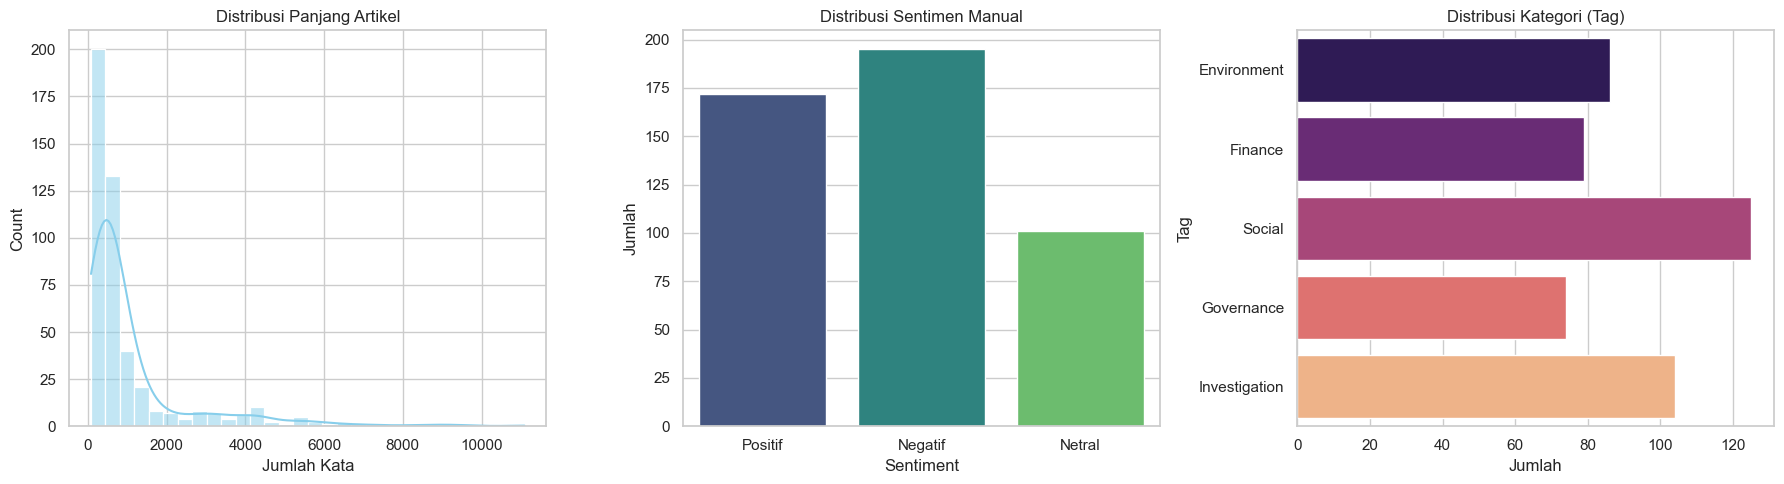

In [8]:
# 3. Visualisasi EDA Dasar
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Distribusi Panjang Kata
sns.histplot(df['panjang_kata'], kde=True, bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Panjang Artikel')
axes[0].set_xlabel('Jumlah Kata')

# Plot B: Distribusi Sentimen
sns.countplot(data=df, x='Sentiment', palette='viridis', order=['Positif', 'Negatif', 'Netral'], ax=axes[1])
axes[1].set_title('Distribusi Sentimen Manual')
axes[1].set_ylabel('Jumlah')

# Plot C: Distribusi Kategori (Tag)
sns.countplot(data=df, y='Tag', palette='magma', ax=axes[2])
axes[2].set_title('Distribusi Kategori (Tag)')
axes[2].set_xlabel('Jumlah')

plt.tight_layout()
plt.show()


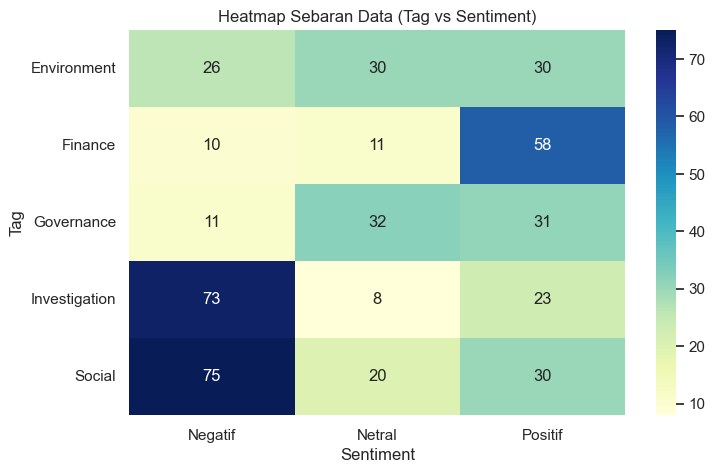

In [9]:
# 4. Tabel Silang (Cross-Tabulation) & Heatmap
cross_tab = pd.crosstab(df['Tag'], df['Sentiment'])
plt.figure(figsize=(8, 5))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap Sebaran Data (Tag vs Sentiment)')
plt.show()

In [10]:
# 5. GATE KEPUTUSAN (PIPELINE B5)
def gate_keputusan_b5(dataframe, min_target=15):
    print("\n" + "="*40)
    print("🚦 GATE B5: STATUS KEBUTUHAN DATA")
    print("="*40)

    ct = pd.crosstab(dataframe['Tag'], dataframe['Sentiment'])
    kekurangan_data = []

    for tag in ct.index:
        for sent in ct.columns:
            jumlah = ct.loc[tag, sent]
            if jumlah < min_target:
                butuh = min_target - jumlah
                kekurangan_data.append({'Tag': tag, 'Sentimen': sent, 'Kurang': butuh})

    if not kekurangan_data:
        print("✅ STATUS: AMAN. Lanjut ke ekstraksi fitur (TF-IDF/POS Tagging).")
    else:
        print("⚠️ STATUS: BUTUH TAMBAHAN ARTIKEL!")
        print("Silakan infokan ke Pipeline A (Tim Scraping) untuk mencari:")
        df_kurang = pd.DataFrame(kekurangan_data)
        display(df_kurang)

# Panggil fungsi gate keputusan
gate_keputusan_b5(df, min_target=5)


🚦 GATE B5: STATUS KEBUTUHAN DATA
✅ STATUS: AMAN. Lanjut ke ekstraksi fitur (TF-IDF/POS Tagging).



### TEXTBLOB SENTIMENT (VIA TRANSLATION)


⏳ Memulai proses translasi ke Bahasa Inggris (Please wait yh)...


   Translasi baris ke-50 selesai...


   Translasi baris ke-100 selesai...


   Translasi baris ke-150 selesai...


   Translasi baris ke-200 selesai...


...

   Translasi baris ke-300 selesai...


   Translasi baris ke-350 selesai...


   Translasi baris ke-400 selesai...


   Translasi baris ke-450 selesai...


✅ Translasi & Scoring selesai dalam 142.70 detik.


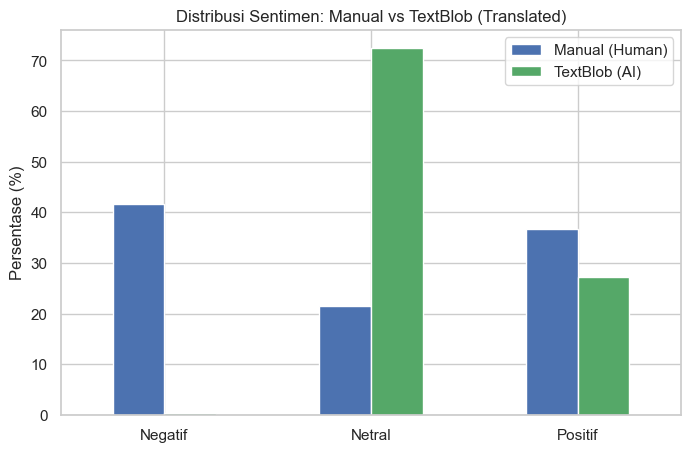

Unique Manual Labels: ['Netral' 'Negatif' 'Positif']
Unique TextBlob Labels: ['Netral' 'Positif' 'Negatif']

--- LAPORAN VALIDASI TEXTBLOB ---
Akurasi: 0.28
              precision    recall  f1-score   support

     Negatif       0.50      0.01      0.01       195
      Netral       0.18      0.59      0.27       101
     Positif       0.57      0.42      0.48       172

    accuracy                           0.28       468
   macro avg       0.41      0.34      0.25       468
weighted avg       0.45      0.28      0.24       468



In [11]:
print("⏳ Memulai proses translasi ke Bahasa Inggris (Please wait yh)...")

# 1. Fungsi Translasi (Aman dari limit API Colab)
def translate_to_english(text):
    try:
        # Batasi 6000 karakter agar tidak error kena limit Google Translate
        text_sliced = str(text)[:6000]
        translated = GoogleTranslator(source='id', target='en').translate(text_sliced)
        return translated
    except Exception as e:
        return "" # Return kosong jika gagal

# 2. Fungsi TextBlob Scoring
def get_textblob_label(text):
    if not text: return 'Netral'

    score = TextBlob(text).sentiment.polarity
    if score > 0.1:
        return 'Positif'
    elif score < -0.1:
        return 'Negatif'
    else:
        return 'Netral'

# 3. Eksekusi Translasi & Scoring
# Gunakan progress_apply jika tqdm sudah diinstall (opsional), jika tidak pakai apply biasa
# Disini kita pakai .apply biasa tapi cetak progress per 50 baris
start_time = time.time()

english_texts = []
for i, text in enumerate(df['teks_bersih']):
    if i % 50 == 0 and i > 0:
        print(f"   Translasi baris ke-{i} selesai...")
    english_texts.append(translate_to_english(text))

df['Teks_English'] = english_texts
df['Sentiment_TextBlob'] = df['Teks_English'].apply(get_textblob_label)

print(f"✅ Translasi & Scoring selesai dalam {(time.time() - start_time):.2f} detik.")

# 4. Evaluasi & Visualisasi TextBlob
dist_manual = df['Sentiment'].value_counts(normalize=True) * 100
dist_blob = df['Sentiment_TextBlob'].value_counts(normalize=True) * 100

df_dist = pd.DataFrame({'Manual (Human)': dist_manual, 'TextBlob (AI)': dist_blob}).fillna(0)

plt.figure(figsize=(8, 5))
df_dist.plot(kind='bar', color=['#4C72B0', '#55A868'], ax=plt.gca())
plt.title('Distribusi Sentimen: Manual vs TextBlob (Translated)')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.show()

# 5. Laporan Performa TextBlob
df_clean = df.dropna(subset=['Sentiment', 'Sentiment_TextBlob']).copy()
df_clean['Sentiment'] = df_clean['Sentiment'].astype(str).str.strip()
df_clean['Sentiment_TextBlob'] = df_clean['Sentiment_TextBlob'].astype(str).str.strip()
print("Unique Manual Labels:", df_clean['Sentiment'].unique())
print("Unique TextBlob Labels:", df_clean['Sentiment_TextBlob'].unique())
print("\n--- LAPORAN VALIDASI TEXTBLOB ---")
print(f"Akurasi: {accuracy_score(df['Sentiment'], df['Sentiment_TextBlob']):.2f}")
print(classification_report(df['Sentiment'], df['Sentiment_TextBlob']))

In [12]:
# Melihat 5 contoh yang manualnya Negatif tapi ditebak lain oleh AI
mask = (df['Sentiment'] == 'Negatif') & (df['Sentiment_TextBlob'] != 'Negatif')
print(df[mask][['teks_bersih', 'Teks_English', 'Sentiment', 'Sentiment_TextBlob']].head())

                                         teks_bersih  \
1  wahana lingkungan hidup indonesia walhi sulawe...   
3  pemerintah didesak hentikan penggusuran ribuan...   
4  penyaluran kredit perbankan ke sektor pertamba...   
6  industri perkebunan khususnya sawit berkomitme...   
9  pembangunan geothermal di kota batu jawa timur...   

                                        Teks_English Sentiment  \
1  The Indonesian environmental agency Walhi Sout...   Negatif   
3                                                      Negatif   
4  Bank Mandiri credit distribution to the coal m...   Negatif   
6  The plantation industry, especially palm oil, ...   Negatif   
9                                                      Negatif   

  Sentiment_TextBlob  
1             Netral  
3             Netral  
4            Positif  
6             Netral  
9             Netral  


### INSET LEXICON DENGAN NEGATION HANDLING

In [13]:
inset_dict = {}   #inisialisasi

print("📂 Memuat InSet Lexicon dari GitHub...")
url_pos = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
url_neg = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

try:
    df_pos = pd.read_csv(url_pos, sep='\t', names=['word', 'weight'])
    df_neg = pd.read_csv(url_neg, sep='\t', names=['word', 'weight'])
    df_pos['weight'] = pd.to_numeric(df_pos['weight'], errors='coerce').fillna(0).astype(int)
    df_neg['weight'] = pd.to_numeric(df_neg['weight'], errors='coerce').fillna(0).astype(int)
    inset_dict = dict(zip(df_pos['word'], df_pos['weight']))
    inset_dict.update(dict(zip(df_neg['word'], df_neg['weight'])))
    print(f"✅ Lexicon termuat: {len(inset_dict)} kata.")
except Exception as e:
    print(f"❌ Gagal memuat Lexicon: {e}")
    print("⚠️  Scoring InSet dilewati — semua artikel akan diberi label 'Netral'.")


📂 Memuat InSet Lexicon dari GitHub...


✅ Lexicon termuat: 9075 kata.


In [14]:
# 1. Fungsi Scoring dengan Negation Handling
def calculate_inset_score_with_negation(text):
    if not isinstance(text, str): return 0

    words = text.lower().split()
    negation_words = ['tidak', 'bukan', 'belum', 'jangan', 'kurang', 'tanpa']
    scores = []

    # Looping dengan index untuk mengecek kata sebelumnya (negation window = 1)
    for i, word in enumerate(words):
        if word in inset_dict:
            base_score = inset_dict[word]

            # Cek 1 kata sebelumnya apakah ada kata negasi
            is_negated = False
            if i > 0 and words[i-1] in negation_words:
                is_negated = True

            # Cek 2 kata sebelumnya (opsional, jika ingin window lebih lebar)
            elif i > 1 and words[i-2] in negation_words:
                is_negated = True

            # Balik polaritas jika kena negasi
            final_score = base_score * -1 if is_negated else base_score
            scores.append(final_score)

    # Hitung rata-rata skor agar panjang berita tidak merusak bobot
    return sum(scores) / len(scores) if len(scores) > 0 else 0


🚀 Menghitung skor sentimen (dilengkapi deteksi negasi)...


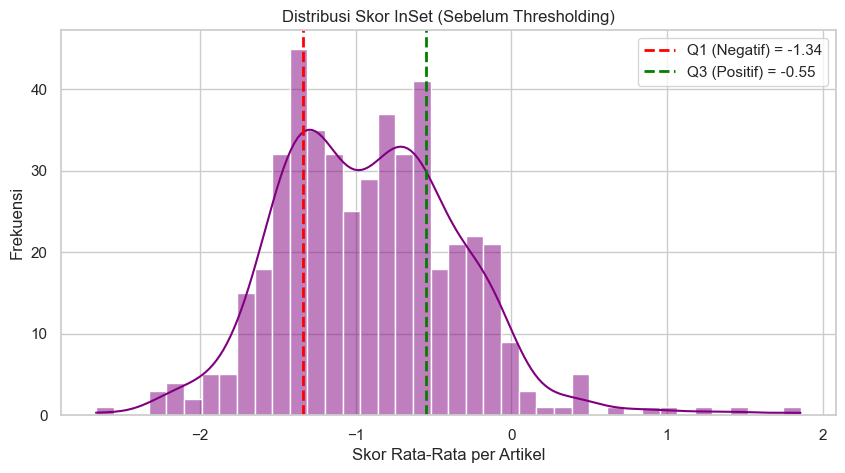

In [15]:

# 2. Terapkan Fungsi dan Hitung Skor Mentah (Mean Score)
print("🚀 Menghitung skor sentimen (dilengkapi deteksi negasi)...")
df['InSet_Score'] = df['teks_bersih'].apply(calculate_inset_score_with_negation)

# 3. Hitung Kuartil untuk Statistical Thresholding
q1 = df['InSet_Score'].quantile(0.25)
q3 = df['InSet_Score'].quantile(0.75)

# 4. Visualisasi Distribusi Skor Murni
plt.figure(figsize=(10, 5))
sns.histplot(df['InSet_Score'], kde=True, bins=40, color='purple')
plt.axvline(q1, color='red', linestyle='--', linewidth=2, label=f'Q1 (Negatif) = {q1:.2f}')
plt.axvline(q3, color='green', linestyle='--', linewidth=2, label=f'Q3 (Positif) = {q3:.2f}')
plt.title('Distribusi Skor InSet (Sebelum Thresholding)')
plt.xlabel('Skor Rata-Rata per Artikel')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()


In [16]:
# 5. Terapkan Label Final Berdasarkan Threshold
def apply_statistical_threshold(score):
    if score > q3:
        return 'Positif'
    elif score < q1:
        return 'Negatif'
    else:
        return 'Netral'

df['Sentiment_InSet'] = df['InSet_Score'].apply(apply_statistical_threshold)

# 6. Laporan Performa InSet
print("\n=== LAPORAN VALIDASI INSET LEXICON ===")
print(f"Akurasi terhadap Manual: {accuracy_score(df['Sentiment'], df['Sentiment_InSet']):.2f}")
print(classification_report(df['Sentiment'], df['Sentiment_InSet']))




=== LAPORAN VALIDASI INSET LEXICON ===
Akurasi terhadap Manual: 0.50
              precision    recall  f1-score   support

     Negatif       0.77      0.46      0.58       195
      Netral       0.26      0.59      0.36       101
     Positif       0.71      0.48      0.57       172

    accuracy                           0.50       468
   macro avg       0.58      0.51      0.50       468
weighted avg       0.64      0.50      0.53       468



### KESIMPULAN PERBANDINGAN F1-SCORE

In [17]:
if 'Sentiment_TextBlob' in df.columns:
    f1_blob = f1_score(df['Sentiment'], df['Sentiment_TextBlob'], average='macro', zero_division=0)
    f1_inset = f1_score(df['Sentiment'], df['Sentiment_InSet'], average='macro', zero_division=0)

    print("\n" + "="*50)
    print("🏆 RINGKASAN PERBANDINGAN METODE VALIDASI")
    print("="*50)
    print(f"{'Metode':<20} | {'F1-Macro':<10} | {'Keterangan'}")
    print("-" * 50)
    print(f"{'TextBlob (Translated)':<20} | {f1_blob:<10.4f} | Rentan bias hasil translasi mesin")
    print(f"{'InSet (+ Negation)':<20} | {f1_inset:<10.4f} | Menangkap struktur B.Indonesia murni")




🏆 RINGKASAN PERBANDINGAN METODE VALIDASI
Metode               | F1-Macro   | Keterangan
--------------------------------------------------
TextBlob (Translated) | 0.2548     | Rentan bias hasil translasi mesin
InSet (+ Negation)   | 0.5032     | Menangkap struktur B.Indonesia murni


# Feature Extraction

### TF-IDF


 [C0] Menghitung TF-IDF...
 Kolom 'teks_bersih' berhasil dikenali sebagai 'clean_text'



 Top 20 Kata Berdasarkan TF-IDF:
energi           0.055476
bank             0.054802
indonesia        0.047222
perusahaan       0.046646
sawit            0.046065
antam            0.045783
mandiri          0.035272
pembiayaan       0.035007
berkelanjutan    0.034449
masyarakat       0.033465
lingkungan       0.033014
triliun          0.031898
sektor           0.031675
listrik          0.030772
mereka           0.029725
warga            0.029683
hijau            0.028295
bri              0.028028
kredit           0.027827
tambang          0.027364
dtype: float64


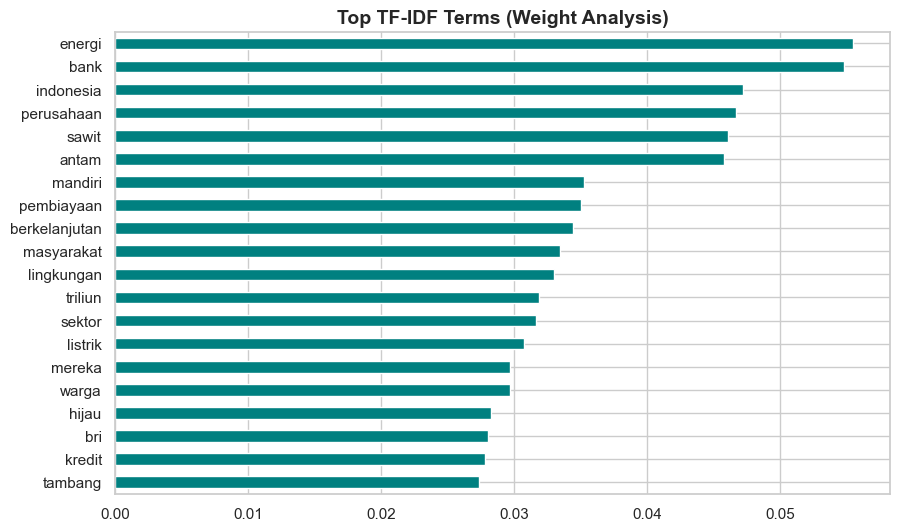

In [18]:
print('\n [C0] Menghitung TF-IDF...')

from sklearn.feature_extraction.text import TfidfVectorizer

# Stopwords sederhana (biar konsisten sama n-gram kamu)
stop_words_id = ['yang', 'dan', 'di', 'dari', 'ke', 'ini', 'itu', 'tidak', 'untuk', 'sebagai', 'kami', 'atau',
                 'dengan', 'telah', 'dalam', 'pada', 'oleh', 'juga', 'akan', 'pt', 'tbk', 'menjadi', 'tersebut', 'lebih', 'salah satu', 'salah satunya', 'tahun']


# 1. STANDARISASI KOLOM (Biar ga KeyError lagi)
if 'clean_text' not in df.columns:
    kandidat = ['teks_bersih', 'Isi Berita', 'text', 'content']
    for k in kandidat:
        if k in df.columns:
            df.rename(columns={k: 'clean_text'}, inplace=True)
            print(f" Kolom '{k}' berhasil dikenali sebagai 'clean_text'")
            break

# 2. EKSEKUSI TF-IDF
tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words=stop_words_id
)
tfidf_matrix = tfidf.fit_transform(df['clean_text'].astype(str))

# Ambil fitur untuk plotting (hanya variabel lokal)
feature_names = tfidf.get_feature_names_out()
mean_tfidf = pd.Series(tfidf_matrix.toarray().mean(axis=0), index=feature_names).sort_values(ascending=False)

print('\n Top 20 Kata Berdasarkan TF-IDF:')
print(mean_tfidf.head(20))

# Plotting TF-IDF
plt.figure(figsize=(10, 6))
mean_tfidf.head(20).plot(kind='barh', color='teal')
plt.title('Top TF-IDF Terms (Weight Analysis)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

### N Gram


 [C2] Ekstraksi Bigram & Trigram dengan CountVectorizer...


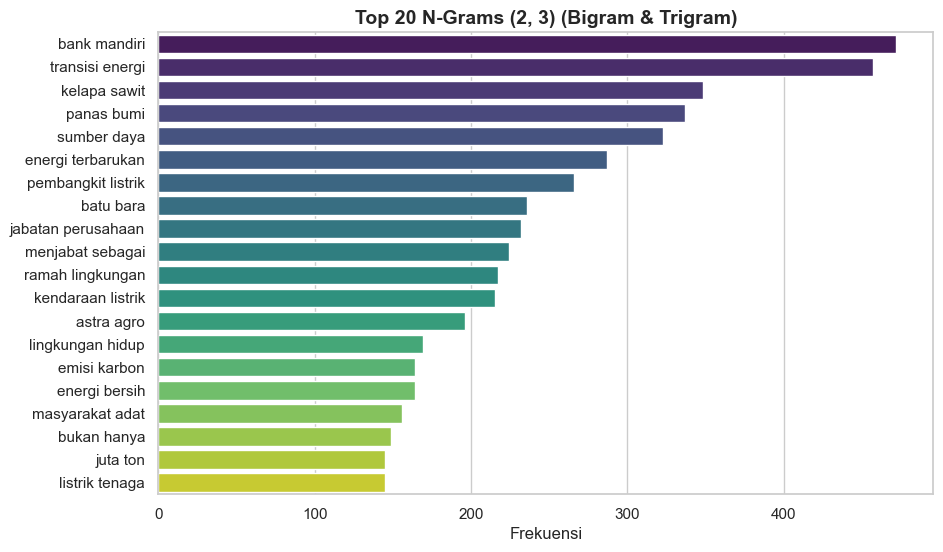

In [19]:
print('\n [C2] Ekstraksi Bigram & Trigram dengan CountVectorizer...')

def plot_top_ngrams(df, ngram_range=(2,3), top_n=20):
    """Fungsi untuk mengekstrak dan plot n-gram menggunakan scikit-learn."""

    stop_words_id = ['yang', 'dan', 'di', 'dari', 'ke', 'ini', 'itu', 'untuk',
                     'dengan', 'dalam', 'pada', 'oleh', 'juga', 'akan', 'pt', 'tbk']

    blacklist_ngrams = {
        "salah satu", "jangka panjang", "2022 lalu", "salah satunya",
        "tata kelola", "kerja sama", "direktur utama", "tidak hanya", "sebagai bagian", "tidak ada", "bagi masyarakat"
    }

    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words=stop_words_id)

    # Ambil teks, pastikan dalam bentuk string
    corpus = df['clean_text'].astype(str).tolist()

    try:
        X = vectorizer.fit_transform(corpus)
        # Hitung frekuensi tiap n-gram
        sum_words = X.sum(axis=0)

        # Ambil semua n-gram dan frekuensinya
        all_words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]

        # FILTER: Buang n-gram yang ada di daftar blacklist
        words_freq_filtered = [wf for wf in all_words_freq if wf[0] not in blacklist_ngrams]

        # Urutkan dari yang frekuensinya paling besar, lalu potong sebanyak top_n (Top 20)
        words_freq = sorted(words_freq_filtered, key=lambda x: x[1], reverse=True)[:top_n]

        # Plotting
        if not words_freq:
            print("Tidak ada n-gram yang tersisa setelah di-filter.")
            return

        words, freqs = zip(*words_freq)
        plt.figure(figsize=(10, 6))
        sns.barplot(x=list(freqs), y=list(words), palette="viridis")
        plt.title(f'Top {top_n} N-Grams {ngram_range} (Bigram & Trigram)', fontsize=14, fontweight='bold')
        plt.xlabel('Frekuensi')
        plt.show()

    except ValueError:
        print("Dataset terlalu kecil atau tidak ada kombinasi kata yang memenuhi syarat.")

# Panggil fungsinya untuk melihat visualisasinya (langsung top 20)
plot_top_ngrams(df, ngram_range=(2,3), top_n=20)

# Analisis Linguistik

In [20]:

!pip install transformers datasets seqeval evaluate accelerate -q

In [21]:
# Bypass PyTorch version check for loading pickle-based weights safely (CVE-2025-32434)
try:
    import transformers.modeling_utils
    transformers.modeling_utils.check_torch_load_is_safe = lambda *args, **kwargs: None
except Exception:
    pass
try:
    import transformers.utils.import_utils
    transformers.utils.import_utils.check_torch_load_is_safe = lambda *args, **kwargs: None
except Exception:
    pass

import ast, json, re, torch
import numpy as np
import pandas as pd
from collections import Counter
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification,
    TrainingArguments, Trainer, DataCollatorForTokenClassification,
    EarlyStoppingCallback
)
import evaluate
from seqeval.metrics import classification_report

MODEL_NAME = "w11wo/indonesian-roberta-base-posp-tagger"

def parse_tokens(token_list):
    if isinstance(token_list, list):
        return token_list
    if not isinstance(token_list, str) or not token_list.strip():
        return []
    for fn in (json.loads, ast.literal_eval):
        try:
            return fn(token_list)
        except:
            pass
    return re.findall(r'"([^"]*)"', token_list)

print("✅ Import selesai")


✅ Import selesai


In [22]:
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification

MODEL_NAME = "w11wo/indonesian-roberta-base-posp-tagger"

# ✅ Load model SELALU, tidak dibungkus kondisi if
print("⏳ Loading model...")
_tok = AutoTokenizer.from_pretrained(MODEL_NAME)
_mdl = AutoModelForTokenClassification.from_pretrained(MODEL_NAME)
_mdl.eval()
print("✅ Model loaded!")
print(f"Label model: {list(_mdl.config.id2label.values())[:5]} ...")

# ── Fungsi tagging per token (1 token = 1 tag) ──
def silver_tag(token_list):
    tokens = parse_tokens(token_list)
    if not tokens:
        return []
    try:
        enc      = _tok(tokens[:128], is_split_into_words=True,
                        return_tensors="pt", truncation=True, max_length=128)
        word_ids = enc.word_ids(0)

        with torch.no_grad():
            logits = _mdl(**enc).logits[0]  # (seq_len, num_labels)

        preds = torch.argmax(logits, dim=-1).tolist()

        # Subword pertama tiap token asli → ambil labelnya
        result = {}
        for sw_idx, wid in enumerate(word_ids):
            if wid is None:
                continue
            if wid not in result:
                result[wid] = _mdl.config.id2label.get(preds[sw_idx], 'UNS')

        return [(tok, result.get(i, 'UNS'))
                for i, tok in enumerate(tokens[:128])]

    except Exception as e:
        print(f"Error: {e}")
        return []

# ── Jalankan ──
print("\n⏳ Silver labeling...")
df['pos_indobert'] = df['tokens'].apply(silver_tag)
total = df['pos_indobert'].apply(lambda x: len(x) > 0).sum()
print(f"✅ {total}/{len(df)} artikel berhasil di-tag")
print(f"\nContoh: {df['pos_indobert'].iloc[0][:10]}")


⏳ Loading model...


Loading weights:   0%|                                                                                     | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|█████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 8363.73it/s]

✅ Model loaded!
Label model: ['B-PPO', 'B-KUA', 'B-ADV', 'B-PRN', 'B-VBI'] ...

⏳ Silver labeling...


✅ 468/468 artikel berhasil di-tag

Contoh: [('choose', 'B-NNP'), ('edition', 'B-NNP'), ('search', 'B-NNP'), ('singapore', 'B-NNP'), ('asia', 'B-NNP'), ('world', 'B-NNP'), ('opinion', 'B-NNP'), ('life', 'B-NNP'), ('business', 'B-NNP'), ('sport', 'B-NNP')]


In [23]:
from collections import Counter

# Definisi label2id secara dinamis dari kolom pos_indobert
all_tags = sorted(set(
    tag for row in df['pos_indobert']
    for _, tag in row
    if tag
))
label2id = {t: i for i, t in enumerate(all_tags)}
id2label = {i: t for t, i in label2id.items()}

print(f"Tag unik ({len(label2id)}): {all_tags}")
print(f"\nDistribusi:")
dist = Counter(t for row in df['pos_indobert'] for _, t in row)
for tag, cnt in dist.most_common():
    print(f"  {tag:10s}: {cnt:,}")

# ============================================================

import numpy as np
from datasets import Dataset, DatasetDict

def build_record(row):
    pairs = row['pos_indobert']
    if not pairs:
        return None
    valid = [(w, label2id[t]) for w, t in pairs if t in label2id]
    if not valid:
        return None
    words, tags = zip(*valid)
    return {"tokens": list(words)[:128], "labels": list(tags)[:128]}

records = [r for _, row in df.iterrows() if (r := build_record(row))]
print(f"Total rekaman valid: {len(records)}")

np.random.seed(42)
idx     = np.random.permutation(len(records))
n_train = int(len(idx) * 0.8)
n_val   = int(len(idx) * 0.1)

tok_ds = DatasetDict({
    "train":      Dataset.from_list([records[i] for i in idx[:n_train]]),
    "validation": Dataset.from_list([records[i] for i in idx[n_train:n_train + n_val]]),
    "test":       Dataset.from_list([records[i] for i in idx[n_train + n_val:]]),
})
print(tok_ds)

Tag unik (21): ['B-$$$', 'B-ADJ', 'B-ADK', 'B-ADV', 'B-ART', 'B-CCN', 'B-CSN', 'B-KUA', 'B-NEG', 'B-NNO', 'B-NNP', 'B-NUM', 'B-PPO', 'B-PRR', 'B-SYM', 'B-UNS', 'B-VBE', 'B-VBI', 'B-VBP', 'B-VBT', 'UNS']

Distribusi:
  B-NNO     : 22,444
  B-NNP     : 18,947
  UNS       : 12,308
  B-NUM     : 2,876
  B-ADJ     : 1,464
  B-VBI     : 382
  B-PPO     : 197
  B-NEG     : 174
  B-CCN     : 99
  B-$$$     : 42
  B-VBT     : 41
  B-SYM     : 39
  B-ADK     : 20
  B-ADV     : 16
  B-VBE     : 14
  B-KUA     : 13
  B-VBP     : 9
  B-UNS     : 8
  B-CSN     : 4
  B-ART     : 2
  B-PRR     : 1
Total rekaman valid: 468
DatasetDict({
    train: Dataset({
        features: ['tokens', 'labels'],
        num_rows: 374
    })
    validation: Dataset({
        features: ['tokens', 'labels'],
        num_rows: 46
    })
    test: Dataset({
        features: ['tokens', 'labels'],
        num_rows: 48
    })
})


In [24]:
# [INFO] Definisi all_tags, label2id, dan id2label dipindahkan ke sel di atasnya
# untuk mencegah NameError saat dijalankan secara berurutan dalam pipeline.
print("✅ label2id & id2label sudah aktif (didefinisikan di sel sebelumnya)")


✅ label2id & id2label sudah aktif (didefinisikan di sel sebelumnya)


In [25]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_and_align(examples):
    enc = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=128,
        padding="max_length",
    )
    all_labels = []
    for i, labels in enumerate(examples["labels"]):
        word_ids, prev_wid, label_ids = enc.word_ids(i), None, []
        for wid in word_ids:
            if wid is None:
                label_ids.append(-100)
            elif wid != prev_wid:
                label_ids.append(labels[wid])
            else:
                label_ids.append(-100)
            prev_wid = wid
        all_labels.append(label_ids)
    enc["labels"] = all_labels
    return enc

tok_ds = tok_ds.map(tokenize_and_align, batched=True, remove_columns=["tokens"])
print("✅ Tokenisasi selesai")
print(f"Contoh label: {tok_ds['train'][0]['labels'][:15]}")


Map:   0%|                                                                                          | 0/374 [00:00<?, ? examples/s]

Map: 100%|██████████████████████████████████████████████████████████████████████████████| 374/374 [00:00<00:00, 3223.05 examples/s]

Map: 100%|██████████████████████████████████████████████████████████████████████████████| 374/374 [00:00<00:00, 3223.05 examples/s]

Map:   0%|                                                                                           | 0/46 [00:00<?, ? examples/s]

Map: 100%|████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 1968.47 examples/s]

Map:   0%|                                                                                           | 0/48 [00:00<?, ? examples/s]

Map: 100%|████████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 2239.90 examples/s]

✅ Tokenisasi selesai
Contoh label: [-100, 10, -100, -100, 10, -100, 10, -100, -100, 10, -100, 9, 9, 10, -100]


In [26]:
import evaluate
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

seqeval = evaluate.load("seqeval")

def compute_metrics(p):
    logits, labels = p
    preds = np.argmax(logits, axis=-1)
    y_pred, y_true = [], []
    for pred_row, label_row in zip(preds, labels):
        tp, tl = [], []
        for pred, label in zip(pred_row, label_row):
            if label != -100:
                tp.append(id2label[pred])
                tl.append(id2label[label])
        y_pred.append(tp)
        y_true.append(tl)
    res = seqeval.compute(predictions=y_pred, references=y_true)
    return {
        "precision": res["overall_precision"],
        "recall":    res["overall_recall"],
        "f1":        res["overall_f1"],
        "accuracy":  res["overall_accuracy"],
    }

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model siap — {total_params:,} parameter")


[transformers] You passed `num_labels=21` which is incompatible to the `id2label` map of length `26`.


Loading weights:   0%|                                                                                     | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|█████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 9114.27it/s]


[transformers] RobertaForTokenClassification LOAD REPORT from: w11wo/indonesian-roberta-base-posp-tagger
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([26, 768]) vs model:torch.Size([21, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([26]) vs model:torch.Size([21])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Model siap — 124,071,189 parameter


In [27]:
USE_GPU = torch.cuda.is_available()
print(f"Device: {'GPU ✅' if USE_GPU else 'CPU ⚠️'}")

steps_per_epoch = len(tok_ds["train"]) // (16 if USE_GPU else 8)
warmup_steps    = int(steps_per_epoch * 5 * 0.1)  # 10% dari total steps
print(f"Steps/epoch: {steps_per_epoch} | Warmup steps: {warmup_steps}")

training_args = TrainingArguments(
    output_dir="./indobert-pos-finetuned",

    # ── Epoch & Batch ──
    num_train_epochs=5,
    per_device_train_batch_size=16 if USE_GPU else 8,
    per_device_eval_batch_size=32  if USE_GPU else 16,

    # ── Optimizer ──
    learning_rate=3e-5,
    weight_decay=0.01,
    warmup_steps=warmup_steps,
    lr_scheduler_type="cosine",

    # ── Evaluasi & Checkpoint ──
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    # ── Logging ──
    logging_steps=50,

    # ── Misc ──
    fp16=USE_GPU,
    seed=42,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tok_ds["train"],
    eval_dataset=tok_ds["validation"],
    processing_class=tokenizer,
    data_collator=DataCollatorForTokenClassification(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print("🚀 Mulai fine-tuning...")
trainer.train()


Device: GPU ✅
Steps/epoch: 23 | Warmup steps: 11


🚀 Mulai fine-tuning...


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.450617,0.854059,0.854059,0.854059,0.854059
2,No log,0.224322,0.914076,0.914076,0.914076,0.914076
3,0.873529,0.200824,0.923575,0.923575,0.923575,0.923575
4,0.873529,0.187411,0.929620,0.929620,0.929620,0.929620
5,0.158200,0.179737,0.933506,0.933506,0.933506,0.933506


Writing model shards:   0%|                                                                                  | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.59it/s]

...

Writing model shards: 100%|██████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.72it/s]

Writing model shards:   0%|                                                                                  | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.39it/s]

Writing model shards: 100%|██████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.39it/s]

TrainOutput(global_step=120, training_loss=0.4511726955572764, metrics={'train_runtime': 44.269, 'train_samples_per_second': 42.242, 'train_steps_per_second': 2.711, 'total_flos': 122177217507840.0, 'train_loss': 0.4511726955572764, 'epoch': 5.0})

In [28]:
print("\n📊 Evaluasi di test set...")
test_result = trainer.evaluate(tok_ds["test"])
print(json.dumps({k: round(v, 4) if isinstance(v, float) else v
                  for k, v in test_result.items()}, indent=2))

# Full per-tag classification report
def full_report(trainer, dataset):
    pred_output          = trainer.predict(dataset)
    logits, labels       = pred_output.predictions, pred_output.label_ids
    preds                = np.argmax(logits, axis=-1)
    true_labels, true_preds = [], []
    for pred_seq, label_seq in zip(preds, labels):
        tl, tp = [], []
        for p_id, l_id in zip(pred_seq, label_seq):
            if l_id != -100:
                tl.append(id2label[l_id])
                tp.append(id2label[p_id])
        true_labels.append(tl)
        true_preds.append(tp)
    return true_labels, true_preds

true_l, true_p = full_report(trainer, tok_ds["test"])
print("\n" + classification_report(true_l, true_p))

# Simpan model
trainer.save_model("./indobert-pos-finetuned")
tokenizer.save_pretrained("./indobert-pos-finetuned")
print("✅ Model tersimpan di ./indobert-pos-finetuned")



📊 Evaluasi di test set...


Training Loss,Validation Loss,Epoch,Precision,Recall,F1,Accuracy
0.158200,0.174297,5,0.937239,0.937239,0.937239,0.937239


{
  "eval_loss": 0.1743,
  "eval_precision": 0.9372,
  "eval_recall": 0.9372,
  "eval_f1": 0.9372,
  "eval_accuracy": 0.9372
}



              precision    recall  f1-score   support

         $$$       0.50      0.57      0.53         7
         ADJ       0.82      0.93      0.87       148
         ADV       0.00      0.00      0.00         1
         CCN       1.00      1.00      1.00        12
         CSN       0.00      0.00      0.00         2
         NEG       0.74      1.00      0.85        20
         NNO       0.93      0.97      0.95      2325
         NNP       0.97      0.90      0.94      1863
         NUM       0.96      0.99      0.98       348
         PPO       0.86      1.00      0.92        24
         SYM       0.00      0.00      0.00         8
         VBE       0.00      0.00      0.00         1
         VBI       0.38      0.80      0.52        30
         VBP       0.00      0.00      0.00         1
         VBT       0.00      0.00      0.00         6

   micro avg       0.94      0.94      0.94      4796
   macro avg       0.48      0.54      0.50      4796
weighted avg       0.94  

Writing model shards:   0%|                                                                                  | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.79it/s]

Writing model shards: 100%|██████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.79it/s]

✅ Model tersimpan di ./indobert-pos-finetuned


In [29]:
import torch

ft_tok = AutoTokenizer.from_pretrained("./indobert-pos-finetuned")
ft_mdl = AutoModelForTokenClassification.from_pretrained("./indobert-pos-finetuned")
ft_mdl.eval()
device = torch.device("cuda" if USE_GPU else "cpu")
ft_mdl.to(device)

def pos_tag_finetuned(token_list):
    tokens = parse_tokens(token_list)
    if not tokens:
        return []
    try:
        enc      = ft_tok(tokens[:128], is_split_into_words=True,
                          return_tensors="pt", truncation=True,
                          max_length=128, padding=True)
        word_ids = enc.word_ids(0)

        with torch.no_grad():
            enc_gpu = {k: v.to(device) for k, v in enc.items()}
            logits  = ft_mdl(**enc_gpu).logits[0]  # (seq_len, num_labels)

        preds    = torch.argmax(logits, dim=-1).cpu().tolist()

        # Ambil prediksi subword pertama per token asli
        result = {}
        for sw_idx, wid in enumerate(word_ids):
            if wid is None:
                continue
            if wid not in result:
                result[wid] = id2label[preds[sw_idx]]

        tagged = [(tok, result.get(i, 'UNS'))
                  for i, tok in enumerate(tokens[:128])]
        return tagged

    except Exception as e:
        return []

print("⏳ Re-tagging dengan model fine-tuned...")
df['pos_finetuned'] = df['tokens'].apply(pos_tag_finetuned)

total = df['pos_finetuned'].apply(lambda x: len(x) > 0).sum()
print(f"✅ {total}/{len(df)} artikel berhasil di-tag ulang")
print(f"\nContoh sebelum : {df['pos_indobert'].iloc[0][:8]}")
print(f"Contoh sesudah : {df['pos_finetuned'].iloc[0][:8]}")


Loading weights:   0%|                                                                                     | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|█████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 9729.75it/s]

⏳ Re-tagging dengan model fine-tuned...


✅ 468/468 artikel berhasil di-tag ulang

Contoh sebelum : [('choose', 'B-NNP'), ('edition', 'B-NNP'), ('search', 'B-NNP'), ('singapore', 'B-NNP'), ('asia', 'B-NNP'), ('world', 'B-NNP'), ('opinion', 'B-NNP'), ('life', 'B-NNP')]
Contoh sesudah : [('choose', 'B-NNP'), ('edition', 'B-NNP'), ('search', 'B-NNP'), ('singapore', 'B-NNP'), ('asia', 'B-NNP'), ('world', 'B-NNP'), ('opinion', 'B-NNP'), ('life', 'B-NNP')]


In [30]:
# ── Debug: cek tag yang keluar dari pos_finetuned ──
from collections import Counter
sample_tags = Counter(pos for row in df['pos_finetuned'] for _, pos in row)
print("Tag dari pos_finetuned:")
print(sample_tags.most_common(20))

Tag dari pos_finetuned:
[('B-NNO', 22894), ('B-NNP', 18128), ('UNS', 12308), ('B-NUM', 2975), ('B-ADJ', 1641), ('B-VBI', 563), ('B-PPO', 222), ('B-NEG', 218), ('B-CCN', 105), ('B-$$$', 40), ('B-ADV', 6)]


Mapping hasil:
  B-NNO           → Noun            (22,894)
  B-NNP           → Proper Noun     (18,128)
  UNS             → Other           (12,308)
  B-NUM           → Number          (2,975)
  B-ADJ           → Adjective       (1,641)
  B-VBI           → Verb            (563)
  B-PPO           → Pronoun         (222)
  B-NEG           → Negation        (218)
  B-CCN           → Conjunction     (105)
  B-$$$           → Other           (40)


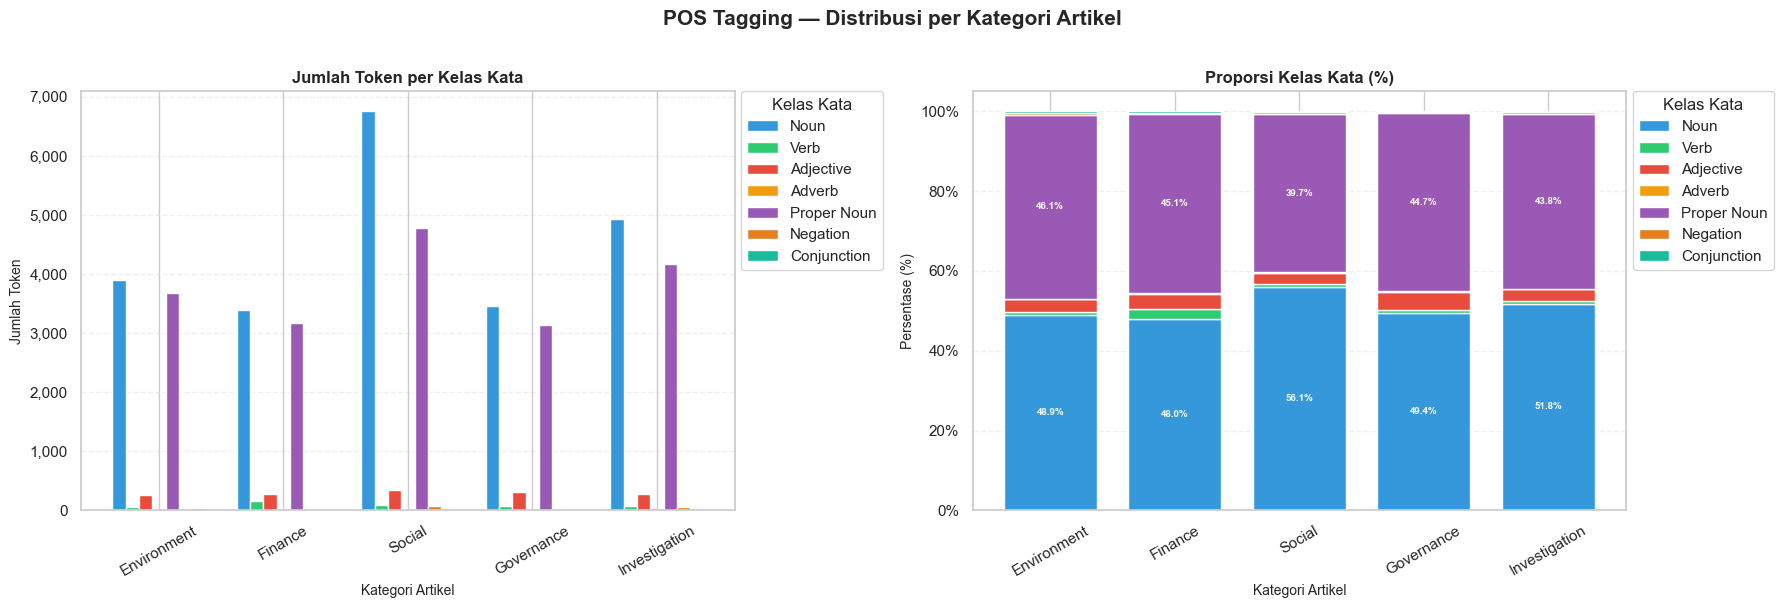

✅ Disimpan: pos_distribusi.png


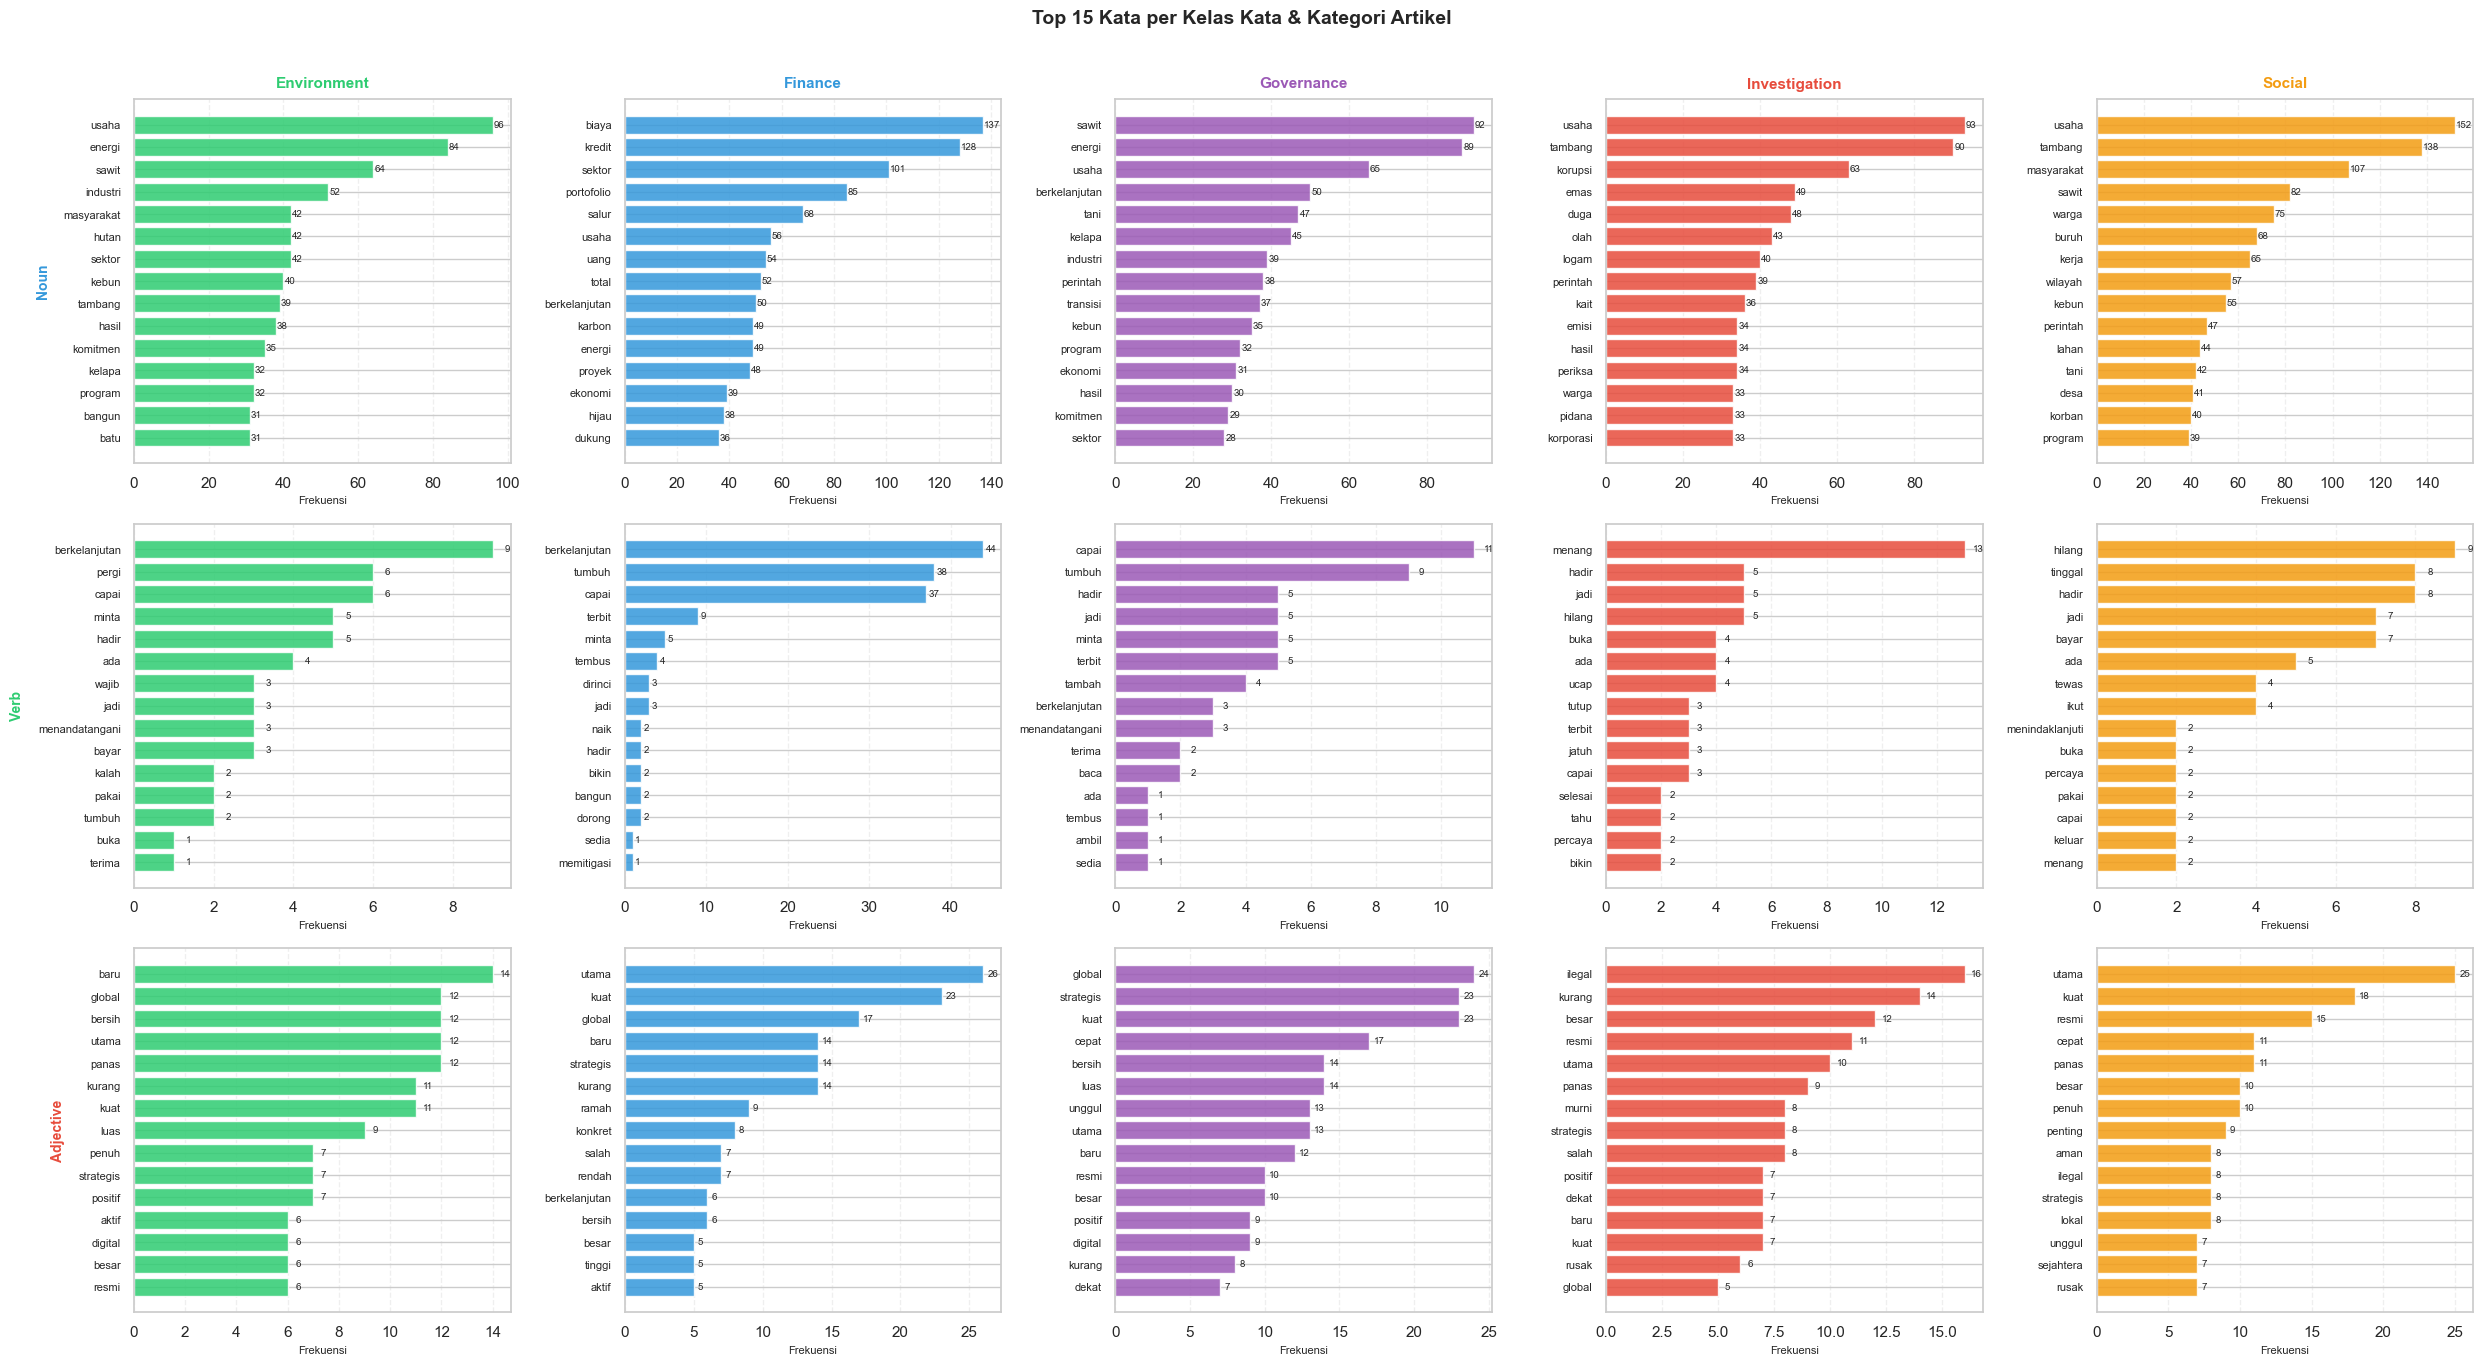

✅ Disimpan: pos_top_kata.png


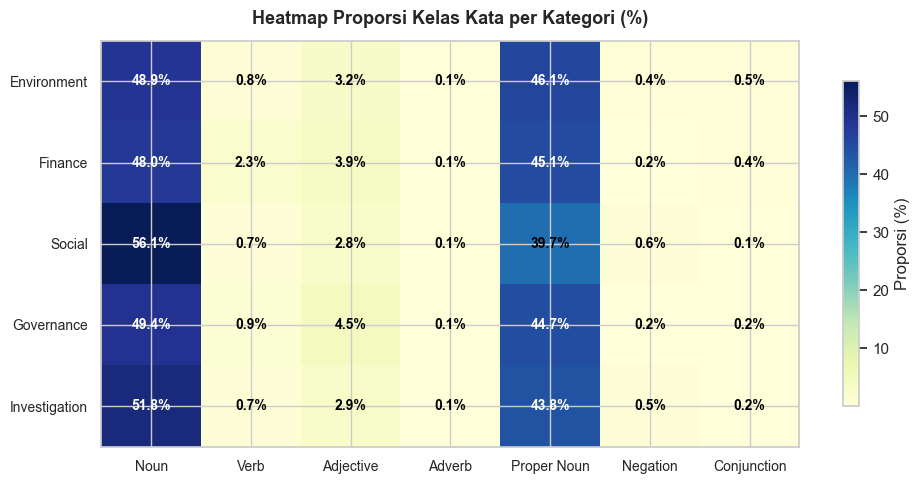

✅ Disimpan: pos_heatmap.png


In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter, defaultdict
import pandas as pd

# Konfigurasi visualisasi POS & Tag (dipindahkan ke atas agar aman saat eksekusi sekuensial)
POS_COL = 'pos_indobert'
MAIN_POS = ['Noun', 'Verb', 'Adjective', 'Adverb', 'Proper Noun', 'Negation', 'Conjunction']
POS_COLORS = {
    'Noun':        '#3498db',
    'Verb':        '#2ecc71',
    'Adjective':   '#e74c3c',
    'Adverb':      '#f39c12',
    'Proper Noun': '#9b59b6',
    'Negation':    '#e67e22',
    'Conjunction': '#1abc9c',
}
TAG_COLORS = {
    'Environment':   '#2ecc71',
    'Finance':       '#3498db',
    'Governance':    '#9b59b6',
    'Investigation': '#e74c3c',
    'Social':        '#f39c12'
}

POS_LABEL_MAP_BASE = {
    'NNP': 'Proper Noun', 'NNO': 'Noun',  'NND': 'Noun',
    'VBT': 'Verb',        'VBI': 'Verb',  'VBP': 'Verb', 'VBL': 'Verb', 'VBE': 'Verb',
    'ADJ': 'Adjective',   'ADV': 'Adverb','ADK': 'Adverb',
    'PPO': 'Pronoun',     'PRR': 'Pronoun','PRN': 'Pronoun','PRI': 'Pronoun','PRK': 'Pronoun',
    'CCN': 'Conjunction', 'CSN': 'Conjunction',
    'ART': 'Particle',    'PAR': 'Particle',
    'KUA': 'Quantifier',  'NUM': 'Number',
    'NEG': 'Negation',    'SYM': 'Symbol', 'UNS': 'Other', '$$$': 'Other',
}

def map_pos(tag):
    # Strip BIO prefix: "B-NNP" → "NNP", "I-VBT" → "VBT"
    clean = tag[2:] if tag.startswith(('B-', 'I-')) else tag
    return POS_LABEL_MAP_BASE.get(clean, 'Other')

# Verifikasi
from collections import Counter
sample_tags = Counter(pos for row in df['pos_finetuned'] for _, pos in row)
print("Mapping hasil:")
for tag, cnt in sample_tags.most_common(10):
    print(f"  {tag:15s} → {map_pos(tag):15s} ({cnt:,})")


# Hitung frekuensi per tag kategori
pos_by_tag = defaultdict(Counter)
for _, row in df.iterrows():
    cat = str(row['Tag'])
    for _, pos in row[POS_COL]:
        mapped = map_pos(pos)
        if mapped in MAIN_POS:
            pos_by_tag[cat][mapped] += 1

pos_df  = pd.DataFrame(pos_by_tag).T.fillna(0).astype(int)
pos_df  = pos_df[[c for c in MAIN_POS if c in pos_df.columns]]
pos_pct = pos_df.div(pos_df.sum(axis=1), axis=0) * 100
colors  = [POS_COLORS[p] for p in pos_df.columns]


fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('POS Tagging — Distribusi per Kategori Artikel',
             fontsize=15, fontweight='bold', y=1.01)

# Count
pos_df.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', width=0.75)
axes[0].set_title('Jumlah Token per Kelas Kata', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kategori Artikel', fontsize=10)
axes[0].set_ylabel('Jumlah Token', fontsize=10)
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend(title='Kelas Kata', bbox_to_anchor=(1.01, 1), borderaxespad=0)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_axisbelow(True)

# Proporsi stacked
pos_pct.plot(kind='bar', stacked=True, ax=axes[1], color=colors,
             edgecolor='white', width=0.75)
axes[1].set_title('Proporsi Kelas Kata (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kategori Artikel', fontsize=10)
axes[1].set_ylabel('Persentase (%)', fontsize=10)
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(0, 105)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
axes[1].legend(title='Kelas Kata', bbox_to_anchor=(1.01, 1), borderaxespad=0)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].set_axisbelow(True)

# Tambah label % di stacked bar
for i, cat in enumerate(pos_pct.index):
    cum = 0
    for pos in pos_pct.columns:
        val = pos_pct.loc[cat, pos]
        if val > 5:  # tampilkan hanya kalau cukup besar
            axes[1].text(i, cum + val / 2, f'{val:.1f}%',
                         ha='center', va='center', fontsize=7,
                         color='white', fontweight='bold')
        cum += val

plt.tight_layout()
plt.savefig('pos_distribusi.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Disimpan: pos_distribusi.png")

TARGET_POS = ['Noun', 'Verb', 'Adjective']
TAGS       = sorted(df['Tag'].dropna().unique())

fig, axes = plt.subplots(len(TARGET_POS), len(TAGS),
                         figsize=(5 * len(TAGS), 4.5 * len(TARGET_POS)))
fig.suptitle('Top 15 Kata per Kelas Kata & Kategori Artikel',
             fontsize=14, fontweight='bold', y=1.01)

for row_i, pos_class in enumerate(TARGET_POS):
    for col_j, tag in enumerate(TAGS):
        ax    = axes[row_i][col_j]
        color = TAG_COLORS.get(tag, '#95a5a6')

        words = [
            w.lower() for _, r in df[df['Tag'] == tag].iterrows()
            for w, p in r[POS_COL]
            if map_pos(p) == pos_class and len(w) > 2
        ]
        top = Counter(words).most_common(15)

        if not top:
            ax.text(0.5, 0.5, 'Tidak ada data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, color='gray')
            ax.axis('off')
        else:
            ws, cs = zip(*top)
            bars = ax.barh(list(ws)[::-1], list(cs)[::-1],
                           color=color, alpha=0.85, edgecolor='white')
            ax.set_xlabel('Frekuensi', fontsize=8)
            ax.tick_params(axis='y', labelsize=8)
            ax.grid(axis='x', alpha=0.3, linestyle='--')
            ax.set_axisbelow(True)
            for bar, cnt in zip(bars, list(cs)[::-1]):
                ax.text(bar.get_width() + 0.3,
                        bar.get_y() + bar.get_height() / 2,
                        str(cnt), va='center', fontsize=7)

        # Header baris & kolom
        if row_i == 0:
            ax.set_title(tag, fontsize=11, fontweight='bold', color=color, pad=8)
        if col_j == 0:
            ax.set_ylabel(pos_class, fontsize=10, fontweight='bold',
                          color=POS_COLORS.get(pos_class, '#333'), labelpad=10)

plt.tight_layout()
plt.savefig('pos_top_kata.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Disimpan: pos_top_kata.png")

import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pos_pct.values, aspect='auto', cmap='YlGnBu')

ax.set_xticks(range(len(pos_pct.columns)))
ax.set_xticklabels(pos_pct.columns, fontsize=10)
ax.set_yticks(range(len(pos_pct.index)))
ax.set_yticklabels(pos_pct.index, fontsize=10)
ax.set_title('Heatmap Proporsi Kelas Kata per Kategori (%)',
             fontsize=13, fontweight='bold', pad=12)

for i in range(len(pos_pct.index)):
    for j in range(len(pos_pct.columns)):
        val = pos_pct.iloc[i, j]
        txt_color = 'white' if val > 40 else 'black'
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=10, color=txt_color, fontweight='bold')

plt.colorbar(im, ax=ax, label='Proporsi (%)', shrink=0.8)
plt.tight_layout()
plt.savefig('pos_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Disimpan: pos_heatmap.png")


### NER using IndoBERT

In [32]:
import ast
import json
import re
from transformers import pipeline

# Load NER model
print(" Loading IndoBERT NER...")
ner_pipeline = pipeline("ner", model="cahya/bert-base-indonesian-NER",
                        aggregation_strategy="simple", device=-1)
print(" NER model loaded!")

def parse_tokens(token_list):
    if isinstance(token_list, list):
        return token_list
    if not isinstance(token_list, str) or not token_list.strip():
        return []
    try:
        return json.loads(token_list)
    except:
        pass
    try:
        return ast.literal_eval(token_list)
    except:
        pass
    tokens = re.findall(r'"([^"]*)"', token_list)
    return tokens if tokens else []

def ekstrak_indobert_ner(token_list):
    tokens = parse_tokens(token_list)
    if not tokens:
        return "", ""
    text = " ".join(tokens[:100])
    try:
        hasil_ner = ner_pipeline(text)
    except Exception:
        return "", ""
    orgs, locs = set(), set()
    for ent in hasil_ner:
        if ent['entity_group'] == 'ORG':
            orgs.add(ent['word'])
        elif ent['entity_group'] == 'LOC':
            locs.add(ent['word'])
    return ", ".join(list(orgs)), ", ".join(list(locs))

# Jalankan ke seluruh df
print("\n Memproses NER seluruh dataset...")
df[['IndoBERT_ORG', 'IndoBERT_LOC']] = df.apply(
    lambda row: pd.Series(ekstrak_indobert_ner(row['tokens'])), axis=1
)
print(" NER selesai!")
display(df[['IndoBERT_ORG', 'IndoBERT_LOC']].head(5))

 Loading IndoBERT NER...


Loading weights:   0%|                                                                                     | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 15959.51it/s]


[transformers] BertForTokenClassification LOAD REPORT from: cahya/bert-base-indonesian-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 NER model loaded!

 Memproses NER seluruh dataset...


 NER selesai!


,IndoBERT_ORG,IndoBERT_LOC
0,"##eds, bumitama agri, ##ion, visual, ##ama, as...",
1,"asa, usaha tambang nikel tua, ##hi, nikel, pt ...","kebun merica, asai"
2,"paulo brasil, hutan lahan energi industri, bid...",
3,##hiyayasan lembaga bantu huk um indonesia ylb...,"pulau pari jakarta, pulau ancam ampas tanah, p..."
4,"batubara, bank mandiri, jalan bank catat, sekt...",


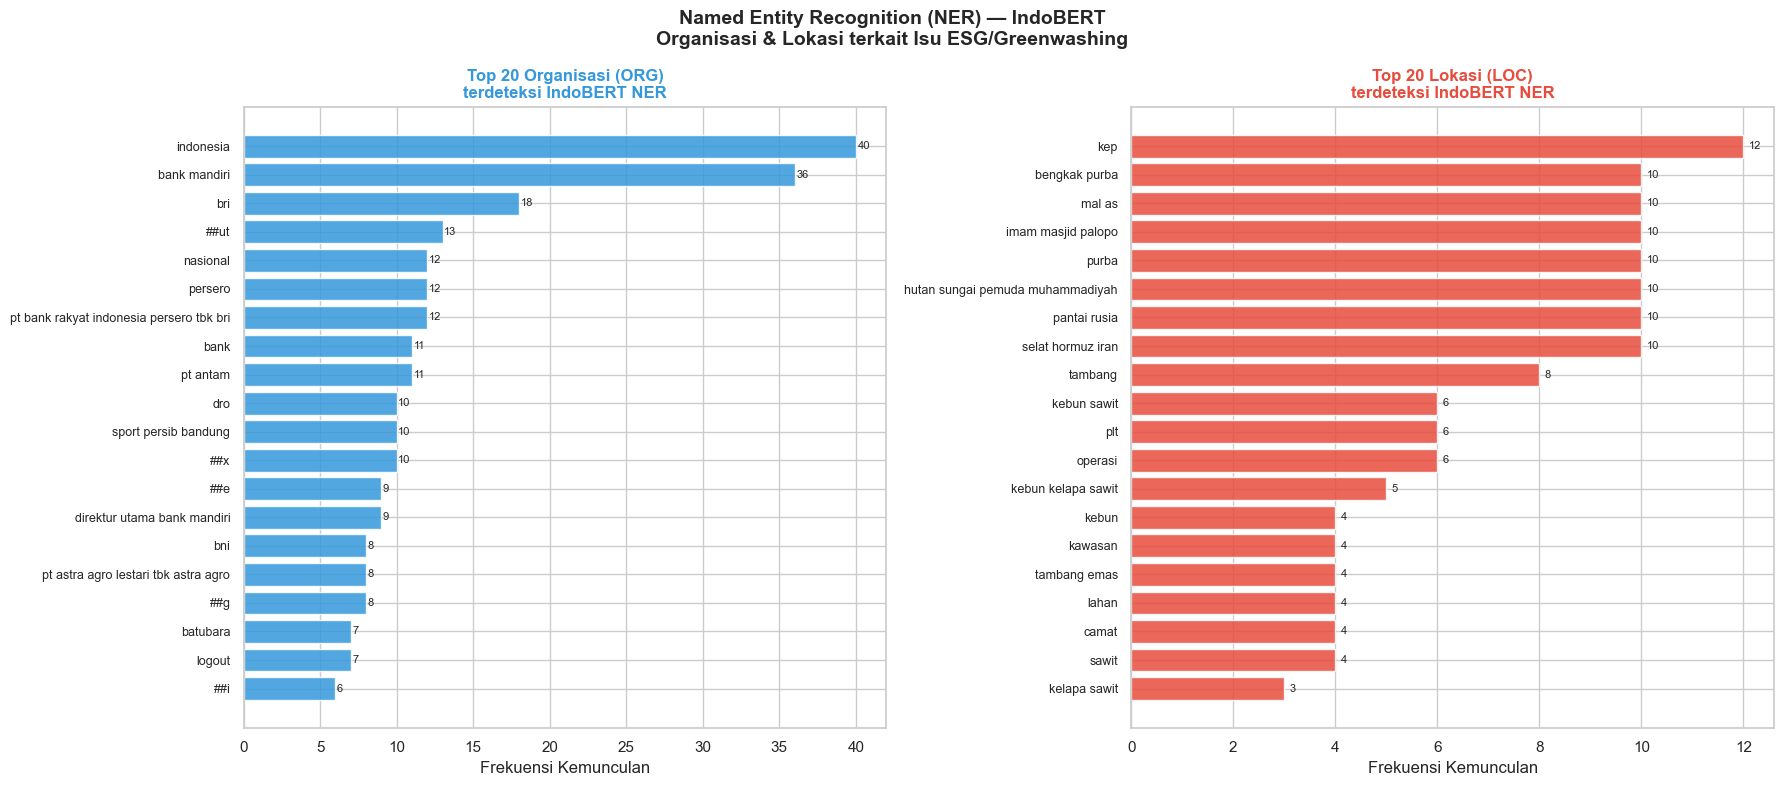

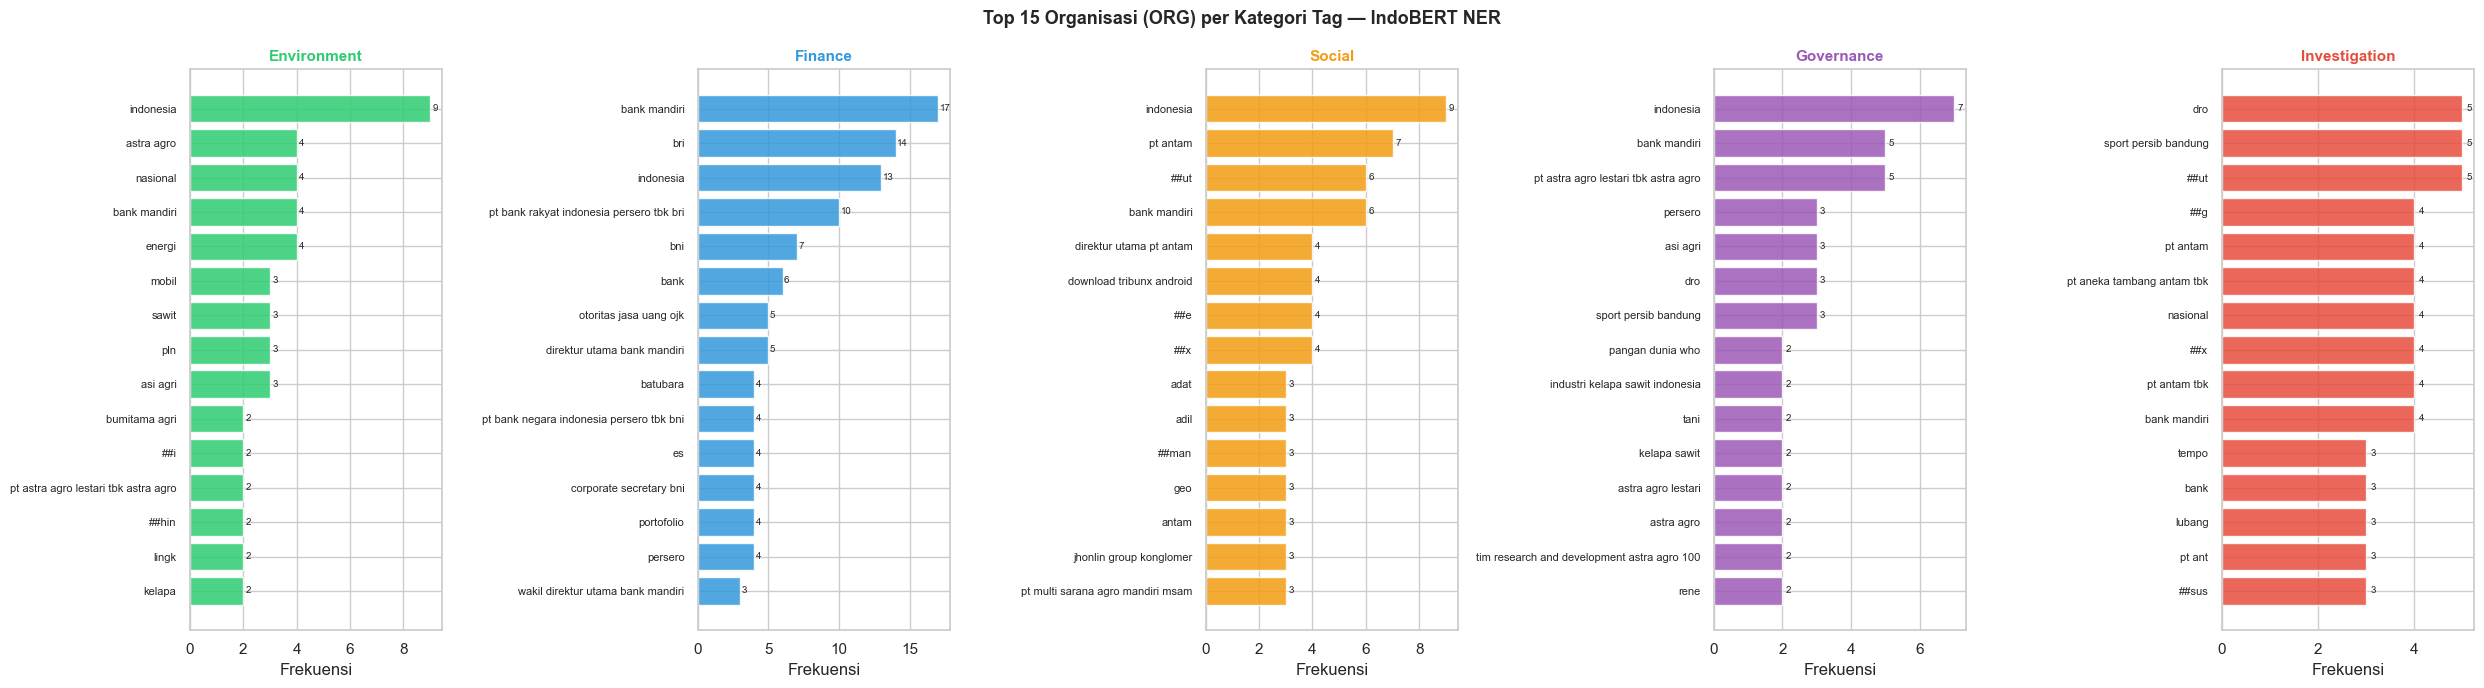

✅ Visualisasi NER tersimpan!


In [33]:
# ── Visualisasi Top ORG & LOC ──
from collections import Counter

# Pecah string kembali jadi list, buang yang kosong
all_orgs = [o.strip() for orgs in df['IndoBERT_ORG'] for o in orgs.split(',') if o.strip()]
all_locs = [l.strip() for locs in df['IndoBERT_LOC'] for l in locs.split(',') if l.strip()]

top_orgs = Counter(all_orgs).most_common(20)
top_locs = Counter(all_locs).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot ORG
if top_orgs:
    words, counts = zip(*top_orgs)
    bars = axes[0].barh(list(words)[::-1], list(counts)[::-1],
                        color='#3498db', alpha=0.85, edgecolor='white')
    axes[0].set_title('Top 20 Organisasi (ORG)\nterdeteksi IndoBERT NER',
                      fontsize=12, fontweight='bold', color='#3498db')
    axes[0].set_xlabel('Frekuensi Kemunculan')
    axes[0].tick_params(axis='y', labelsize=9)
    for bar, cnt in zip(bars, list(counts)[::-1]):
        axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                     str(cnt), va='center', fontsize=8)

# Plot LOC
if top_locs:
    words, counts = zip(*top_locs)
    bars2 = axes[1].barh(list(words)[::-1], list(counts)[::-1],
                         color='#e74c3c', alpha=0.85, edgecolor='white')
    axes[1].set_title('Top 20 Lokasi (LOC)\nterdeteksi IndoBERT NER',
                      fontsize=12, fontweight='bold', color='#e74c3c')
    axes[1].set_xlabel('Frekuensi Kemunculan')
    axes[1].tick_params(axis='y', labelsize=9)
    for bar, cnt in zip(bars2, list(counts)[::-1]):
        axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                     str(cnt), va='center', fontsize=8)

plt.suptitle('Named Entity Recognition (NER) — IndoBERT\nOrganisasi & Lokasi terkait Isu ESG/Greenwashing',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ner_org_loc_indobert.png', bbox_inches='tight')
plt.show()

# ── Bonus: ORG per Kategori Tag ──
fig, axes = plt.subplots(1, len(df['Tag'].dropna().unique()), figsize=(5 * len(df['Tag'].dropna().unique()), 7))

TAG_COLORS_MAP = {
    'Environment':   '#2ecc71',
    'Finance':       '#3498db',
    'Governance':    '#9b59b6',
    'Investigation': '#e74c3c',
    'Social':        '#f39c12'
}

for ax, tag in zip(axes, df['Tag'].dropna().unique()):
    subset_orgs = [
        o.strip()
        for orgs in df[df['Tag']==tag]['IndoBERT_ORG']
        for o in orgs.split(',') if o.strip()
    ]
    top = Counter(subset_orgs).most_common(15)
    if not top:
        ax.set_visible(False)
        continue
    words, counts = zip(*top)
    color = TAG_COLORS_MAP.get(tag, '#95a5a6')
    bars = ax.barh(list(words)[::-1], list(counts)[::-1],
                   color=color, alpha=0.85, edgecolor='white')
    ax.set_title(tag, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Frekuensi')
    ax.tick_params(axis='y', labelsize=8)
    for bar, cnt in zip(bars, list(counts)[::-1]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                str(cnt), va='center', fontsize=7)

plt.suptitle('Top 15 Organisasi (ORG) per Kategori Tag — IndoBERT NER',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ner_org_per_tag.png', bbox_inches='tight')
plt.show()
print('✅ Visualisasi NER tersimpan!')

In [34]:
print('\n⏳ Menyimpan hasil ke CSV...')
df.to_csv('IndoBERT.csv', index=False)
print('✅ File berhasil dibuat')


⏳ Menyimpan hasil ke CSV...


✅ File berhasil dibuat


# GPE


⏳ 1. Loading Model IndoBERT-NER (NERGrit - Full AI GPE, LOC, ORG Detection)...


Loading weights:   0%|                                                                                     | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 20140.59it/s]

⏳ 2. Mengekstrak Ulang ORG, LOC (Fisik), dan GPE (Administratif) pada seluruh data...


⏳ 3. Membuat Visualisasi Perbandingan (ORG vs LOC vs GPE)...


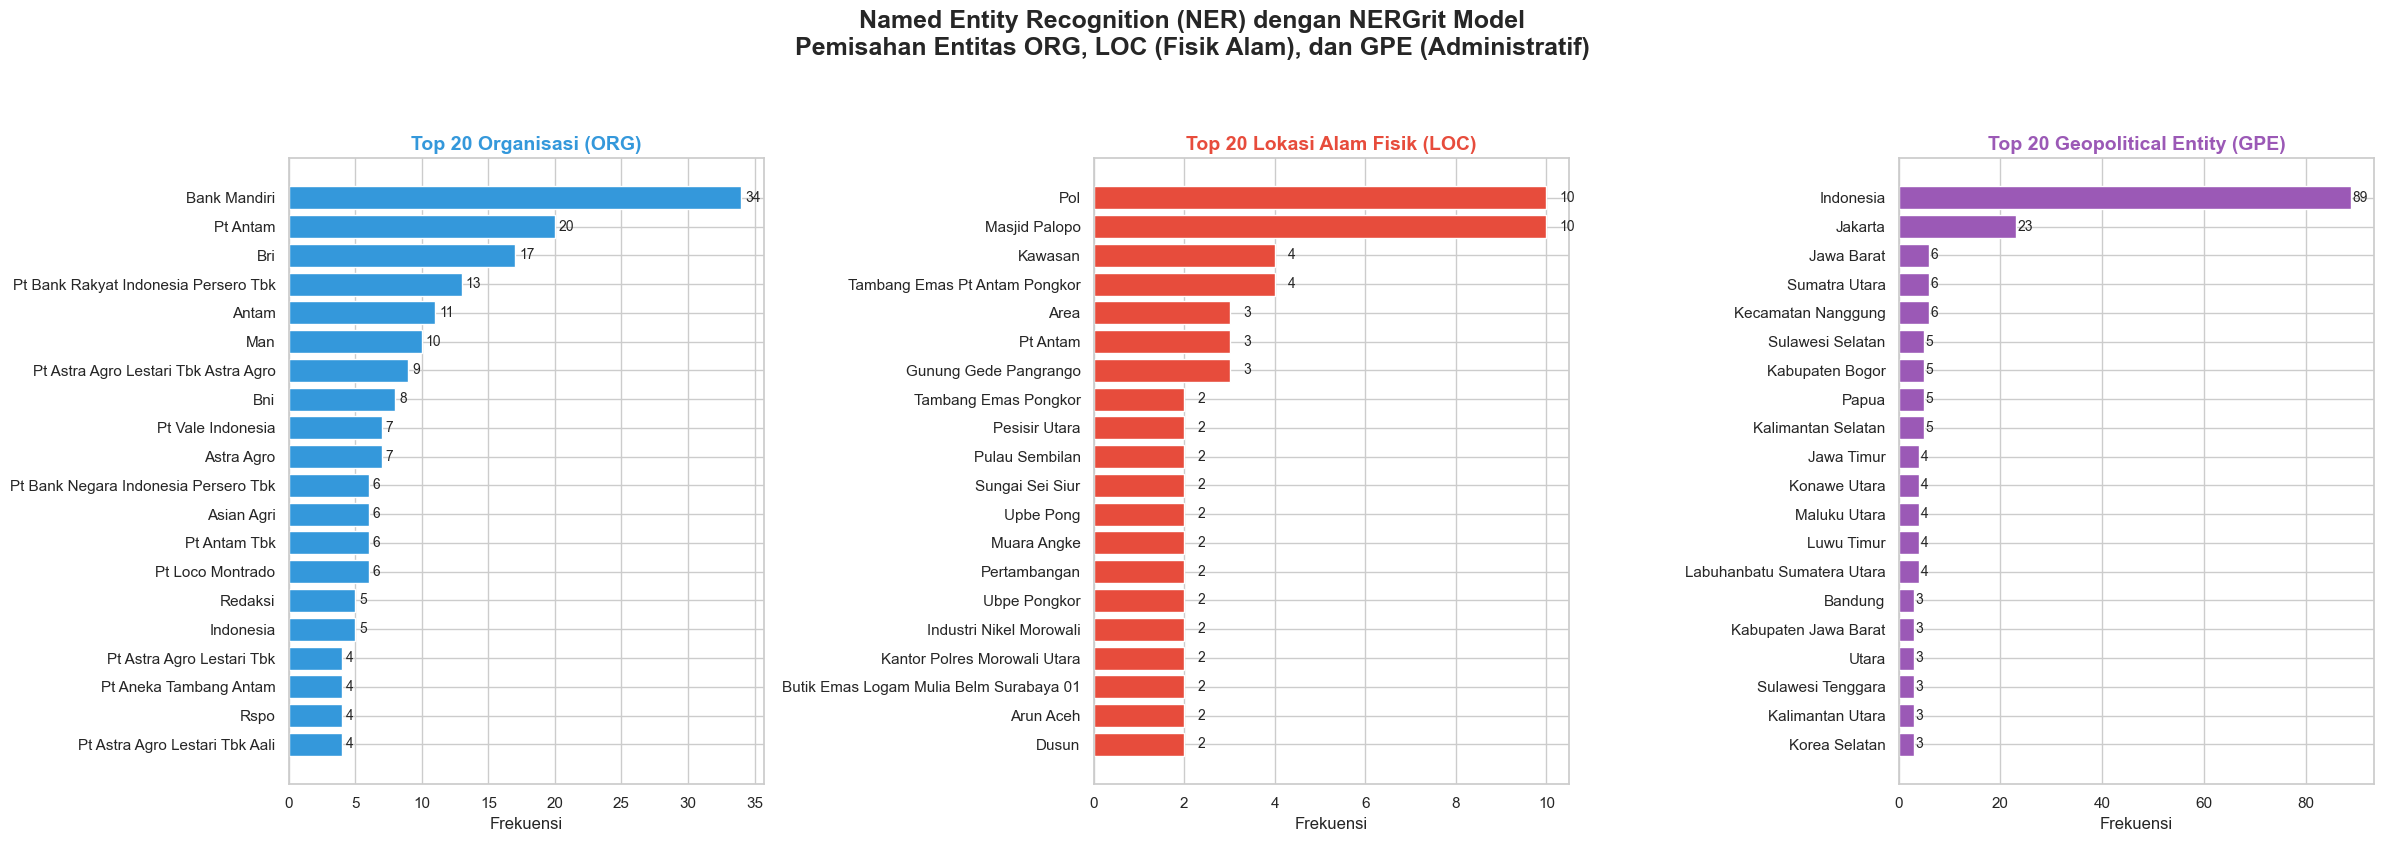

✅ SELESAI! Visualisasi perbandingan berhasil dibuat dan disimpan sebagai 'output_NER_Lengkap_ORG_LOC_GPE.png'!


✅ IndoBERT.csv updated at: IndoBERT.csv


✅ IndoBERT.csv updated at: ../data/IndoBERT.csv


✅ IndoBERT.csv updated at: data/IndoBERT.csv
✅ IndoBERT.csv updated with NER columns!


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from transformers import pipeline

print("⏳ 1. Loading Model IndoBERT-NER (NERGrit - Full AI GPE, LOC, ORG Detection)...")
# Menggunakan model NERGrit yang sudah SOTA (State-of-the-Art)
ner_pipeline = pipeline(
    "ner",
    model="bryanahusna/my-nergrit-model",
    aggregation_strategy="simple",
    device=-1
)

# --- DAFTAR KATA BLACKLIST (Agar visualisasi rapi dari noise/singkatan aneh) ---
BLACKLIST_WORDS = ['kep', 'ut', 'mal as', 'tbk', 'pt', 'tni', 'polri', 'llc', 'corp', 'tbk.', 'kab', 'prov']

def ekstrak_ner_all(teks):
    teks_potong = str(teks)[:500] # Batasi 500 karakter agar komputasi ringan dan cepat
    try:
        hasil_ner = ner_pipeline(teks_potong)
    except:
        return "", "", ""

    orgs, locs, gpes = set(), set(), set()

    for ent in hasil_ner:
        word = ent['word'].strip().lower()

        # FIX TOKEN BOCOR (Membersihkan sisa tokenisasi ##)
        word = word.replace("##", "")

        # FILTERING NOISE
        if len(word) <= 2 and word not in ['ri', 'as', 'uk']:
            continue
        if word in BLACKLIST_WORDS:
            continue

        word_capitalized = word.title()

        # KATEGORISASI ENTITAS MURNI DARI AI
        if ent['entity_group'] == 'ORG':
            orgs.add(word_capitalized)
        elif ent['entity_group'] == 'LOC':
            locs.add(word_capitalized) # Fisik Alam (Sungai, Hutan, Tambang)
        elif ent['entity_group'] == 'GPE':
            gpes.add(word_capitalized) # Geopolitik/Administratif (Negara, Kota)

    return ", ".join(list(orgs)), ", ".join(list(locs)), ", ".join(list(gpes))

print("⏳ 2. Mengekstrak Ulang ORG, LOC (Fisik), dan GPE (Administratif) pada seluruh data...")
# Menyimpan ke kolom baru agar bisa dibandingkan dengan hasil temanmu
df[['IndoBERT_ORG_Baru', 'IndoBERT_LOC_Baru', 'IndoBERT_GPE_Baru']] = df.apply(
    lambda row: pd.Series(ekstrak_ner_all(row['clean_text'] if 'clean_text' in row else row['teks_bersih'])), axis=1
)

print("⏳ 3. Membuat Visualisasi Perbandingan (ORG vs LOC vs GPE)...")

def get_top_20(column_name):
    semua_entitas = []
    for baris in df[column_name].dropna():
        if baris:
            entitas_terpisah = [ent.strip() for ent in baris.split(',') if ent.strip()]
            semua_entitas.extend(entitas_terpisah)
    return Counter(semua_entitas).most_common(20)

top_orgs = get_top_20('IndoBERT_ORG_Baru')
top_locs = get_top_20('IndoBERT_LOC_Baru')
top_gpes = get_top_20('IndoBERT_GPE_Baru')

# Menggambar 3 Grafik Berdampingan (Subplots)
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('Named Entity Recognition (NER) dengan NERGrit Model\nPemisahan Entitas ORG, LOC (Fisik Alam), dan GPE (Administratif)', fontsize=18, fontweight='bold', y=1.05)

# Plot 1: ORG
if top_orgs:
    words, counts = zip(*top_orgs)
    bars = axes[0].barh(list(words)[::-1], list(counts)[::-1], color='#3498db', edgecolor='white')
    axes[0].set_title('Top 20 Organisasi (ORG)', fontsize=14, fontweight='bold', color='#3498db')
    axes[0].set_xlabel('Frekuensi', fontsize=12)
    for bar, cnt in zip(bars, list(counts)[::-1]):
        axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, str(cnt), va='center', fontsize=10)

# Plot 2: LOC
if top_locs:
    words, counts = zip(*top_locs)
    bars = axes[1].barh(list(words)[::-1], list(counts)[::-1], color='#e74c3c', edgecolor='white')
    axes[1].set_title('Top 20 Lokasi Alam Fisik (LOC)', fontsize=14, fontweight='bold', color='#e74c3c')
    axes[1].set_xlabel('Frekuensi', fontsize=12)
    for bar, cnt in zip(bars, list(counts)[::-1]):
        axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, str(cnt), va='center', fontsize=10)

# Plot 3: GPE
if top_gpes:
    words, counts = zip(*top_gpes)
    bars = axes[2].barh(list(words)[::-1], list(counts)[::-1], color='#9b59b6', edgecolor='white')
    axes[2].set_title('Top 20 Geopolitical Entity (GPE)', fontsize=14, fontweight='bold', color='#9b59b6')
    axes[2].set_xlabel('Frekuensi', fontsize=12)
    for bar, cnt in zip(bars, list(counts)[::-1]):
        axes[2].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, str(cnt), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('output_NER_Lengkap_ORG_LOC_GPE.png', bbox_inches='tight', dpi=300)
plt.show()

print("✅ SELESAI! Visualisasi perbandingan berhasil dibuat dan disimpan sebagai 'output_NER_Lengkap_ORG_LOC_GPE.png'!")
# Export and save DataFrame with new NER columns
# Export and save DataFrame with new NER columns robustly
import os
output_paths = ['IndoBERT.csv', '../data/IndoBERT.csv', 'data/IndoBERT.csv']
for path in output_paths:
    try:
        parent = os.path.dirname(path)
        if parent and not os.path.exists(parent):
            os.makedirs(parent, exist_ok=True)
        df.to_csv(path, index=False)
        print(f"✅ IndoBERT.csv updated at: {path}")
    except Exception as e:
        print(f"⚠️ Gagal menyimpan ke {path}: {e}")
print("✅ IndoBERT.csv updated with NER columns!")
